# Notebook: Qualitative Evaluation (Experts 3, 4 & 5) -- Experiment 1

## Initial Setup

In [17]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("Set2")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 100)

pd.set_option('display.notebook_repr_html', True)

def create_seaborn_boxplot(data, x, y, ax, title, ylabel, xlabel, scale_range=None):
    colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854', '#ffd92f', '#e5c494', '#b3b3b3']
    unique_vals = sorted(data[x].unique())
    palette = colors[:len(unique_vals)]
    
    sns.boxplot(data=data, x=x, y=y, ax=ax, palette=palette,
                medianprops={'color': 'black', 'linewidth': 2.5, 'linestyle': ':'})
    
    for i, val in enumerate(unique_vals):
        mean_val = data[data[x] == val][y].mean()
        ax.scatter(i, mean_val, color='red', marker='D', s=50, zorder=3, 
                  edgecolor='darkred', linewidth=1)
    
    label_mapping = {
        'anthropic': 'Anthropic',
        'openai': 'OpenAI', 
        'google': 'Google',
        'deepseek': 'DeepSeek',
        'common': 'Common',
        'complex': 'Complex',
        'script': 'Script',
        'transcript': 'Transcript', 
        'tanenbaum': 'Tanenbaum',
        'script_manipulated': 'Script (Manipulated)',
        'exp1a': 'Exp 1a',
        'exp1b': 'Exp 1b'
    }
    
    current_labels = [tick.get_text() for tick in ax.get_xticklabels()]
    new_labels = [label_mapping.get(label, label) for label in current_labels]
    ax.set_xticklabels(new_labels, rotation=0)
    
    if scale_range:
        ax.set_ylim(scale_range)
        if scale_range == (0, 10):
            title += " (0-10 scale)"
        elif scale_range == (0, 70):
            title += " (0-70 scale)"
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=11, labelpad=15)
    ax.set_xlabel(xlabel, fontsize=11, labelpad=10)
    ax.grid(True, alpha=0.3)

BASE_PROJECT_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))

expert_base_path = os.path.join(BASE_PROJECT_PATH, "20_experiments/60_analyses/csv/qualitative/exp1/experts")
hint_base_path = os.path.join(BASE_PROJECT_PATH, "20_experiments/60_analyses/csv/qualitative/exp1/hints")

output_base_path = os.path.join(BASE_PROJECT_PATH, "40_evaluation/exp1/qualitative")
output_tables_path = os.path.join(output_base_path, "tables")
output_plots_path = os.path.join(output_base_path, "plots")

for path in [output_tables_path, output_plots_path]:
    os.makedirs(path, exist_ok=True)

tables = {}
plots = {}

print(f"Setup completed")
print(f"Output tables: {output_tables_path}")
print(f"Output plots: {output_plots_path}")

Setup completed
Output tables: /home/malde/git/bachelor-thesis/40_evaluation/exp1/qualitative/tables
Output plots: /home/malde/git/bachelor-thesis/40_evaluation/exp1/qualitative/plots


## Data Loading and Preprocessing

In [18]:
def load_and_prepare_data():
    
    hint_exp1a = pd.read_csv(os.path.join(hint_base_path, "exp1a_hints.csv"))
    hint_exp1b = pd.read_csv(os.path.join(hint_base_path, "exp1b_hints.csv"))
    
    # Load all three experts data with proper CSV handling
    experts_data = {}
    for expert in [3, 4, 5]:
        expert_key = f'expert_{expert}'
        try:
            exp1a_path = os.path.join(expert_base_path, expert_key, "exp1a.csv")
            exp1b_path = os.path.join(expert_base_path, expert_key, "exp1b.csv")
            
            # Try different separators based on expert
            if expert == 4:
                # Expert 4 uses semicolons
                exp1a_data = pd.read_csv(exp1a_path, sep=';', quotechar='"')
                exp1b_data = pd.read_csv(exp1b_path, sep=';', quotechar='"')
            else:
                # Other experts use commas
                exp1a_data = pd.read_csv(exp1a_path, quotechar='"', escapechar='\\')
                exp1b_data = pd.read_csv(exp1b_path, quotechar='"', escapechar='\\')
            
            experts_data[expert_key] = {
                'exp1a': exp1a_data,
                'exp1b': exp1b_data
            }
            experts_data[expert_key]['exp1a']['expert'] = expert_key
            experts_data[expert_key]['exp1b']['expert'] = expert_key
            
            print(f"Loaded {expert_key}: Exp1a={len(experts_data[expert_key]['exp1a'])}, Exp1b={len(experts_data[expert_key]['exp1b'])}")
            
        except Exception as e:
            print(f"Error loading {expert_key}: {e}")
            continue
    
    if not experts_data:
        print("No expert data could be loaded!")
        return None, None, None, None, None
    
    # Combine all experts data
    exp1a_combined = pd.concat([data['exp1a'] for data in experts_data.values()], ignore_index=True)
    exp1b_combined = pd.concat([data['exp1b'] for data in experts_data.values()], ignore_index=True)
    
    # Add hint information - repeat hints for each expert
    hint_multiplier = len(experts_data)
    exp1a_hints_extended = pd.concat([hint_exp1a[['llm', 'prompt_type']]] * hint_multiplier, ignore_index=True)
    exp1b_hints_extended = pd.concat([hint_exp1b[['llm', 'prompt_type']]] * hint_multiplier, ignore_index=True)
    
    # Merge data carefully
    exp1a_df = exp1a_combined.copy()
    exp1b_df = exp1b_combined.copy()
    
    # Add missing columns from hints
    for col in ['llm', 'prompt_type']:
        if col not in exp1a_df.columns:
            exp1a_df[col] = exp1a_hints_extended[col].values
        if col not in exp1b_df.columns:
            exp1b_df[col] = exp1b_hints_extended[col].values
    
    numeric_cols_1a = ['relevance', 'clarity', 'answerability', 'challenging', 'value', 'language', 'correctness']
    numeric_cols_1b = ['relevance', 'clarity', 'answerability', 'challenging', 'value', 'language', 'manipulation_handling']
    
    # Clean and convert numeric columns to integers
    print("\nKonvertiere Bewertungen zu Integern...")
    for df, cols, exp_name in [(exp1a_df, numeric_cols_1a, "1a"), (exp1b_df, numeric_cols_1b, "1b")]:
        for col in cols:
            if col in df.columns:
                print(f"  Processing {exp_name}.{col}...")
                
                # Erstelle Debug-Info vor der Konvertierung
                non_numeric_before = df[col].apply(lambda x: not pd.isna(x) and not isinstance(x, (int, float))).sum()
                if non_numeric_before > 0:
                    print(f"    Found {non_numeric_before} non-numeric values before cleaning")
                
                # Bereinige ungültige Werte (aber behalte 0!)
                df[col] = df[col].replace(['??', '???', '', ' ', 'nan', 'NaN', 'NULL', 'null'], np.nan)
                
                # Konvertiere zu numeric (float first)
                df[col] = pd.to_numeric(df[col], errors='coerce')
                
                # Konvertiere zu Integer (behalte NaN bei)
                # Verwende 'Int64' dtype für nullable integers
                df[col] = df[col].astype('Int64')
                
                # Prüfe Wertebereich (0-10 für alle Kriterien)
                valid_data = df[col].dropna()
                if len(valid_data) > 0:
                    min_val = valid_data.min()
                    max_val = valid_data.max()
                    
                    # Prüfe erlaubten Bereich (0-10 für alle Kriterien)
                    valid_range = (0, 10)
                    
                    # Warnung bei Werten außerhalb des Bereichs
                    out_of_range = valid_data[(valid_data < valid_range[0]) | (valid_data > valid_range[1])]
                    if len(out_of_range) > 0:
                        print(f"    WARNING: {len(out_of_range)} values outside range {valid_range}")
                        # Entferne Werte außerhalb des gültigen Bereichs
                        df.loc[(df[col] < valid_range[0]) | (df[col] > valid_range[1]), col] = np.nan
                        df[col] = df[col].astype('Int64')
                    
                    print(f"    Range: {min_val}-{max_val}, Valid entries: {len(valid_data)}")
                else:
                    print(f"    No valid data found")
                
                # Debug: Prüfe finale Datentypen
                print(f"    Final dtype: {df[col].dtype}")
    
    exp1a_df['experiment'] = 'exp1a'
    exp1b_df['experiment'] = 'exp1b'
    
    # Handle input_source naming
    if 'input_source' in exp1b_df.columns:
        exp1b_df['input_source'] = exp1b_df['input_source'].replace('script', 'script_manipulated')
    
    # Calculate completion rates
    exp1a_filled = exp1a_df[numeric_cols_1a].notna().sum().sum()
    exp1a_total = len(exp1a_df) * len(numeric_cols_1a)
    exp1b_filled = exp1b_df[numeric_cols_1b].notna().sum().sum()
    exp1b_total = len(exp1b_df) * len(numeric_cols_1b)
    
    print(f"\nData loaded for {len(experts_data)} experts")
    print(f"Completion rates:")
    print(f"  Exp 1a: {exp1a_filled}/{exp1a_total} ({100*exp1a_filled/exp1a_total:.1f}%)")
    print(f"  Exp 1b: {exp1b_filled}/{exp1b_total} ({100*exp1b_filled/exp1b_total:.1f}%)")
    
    # Berechne total_score (verwende fillvalue=0 für Integer summation)
    exp1a_df['total_score'] = exp1a_df[numeric_cols_1a].sum(axis=1, skipna=True)
    exp1b_df['total_score'] = exp1b_df[numeric_cols_1b].sum(axis=1, skipna=True)
    
    # Zusätzliche Datentyp-Validierung für experts_data
    print(f"\nValidiere Datentypen in experts_data...")
    for expert_key in experts_data:
        for exp_type in ['exp1a', 'exp1b']:
            cols = numeric_cols_1a if exp_type == 'exp1a' else numeric_cols_1b
            for col in cols:
                if col in experts_data[expert_key][exp_type].columns:
                    # Bereinige auch die einzelnen Expert-DataFrames
                    experts_data[expert_key][exp_type][col] = experts_data[expert_key][exp_type][col].replace(['??', '???', '', ' ', 'nan', 'NaN', 'NULL', 'null'], np.nan)
                    experts_data[expert_key][exp_type][col] = pd.to_numeric(experts_data[expert_key][exp_type][col], errors='coerce')
                    
                    # Behalte 0-Werte für alle Kriterien!
                    experts_data[expert_key][exp_type][col] = experts_data[expert_key][exp_type][col].astype('Int64')
    
    print(f"Datentyp-Konvertierung abgeschlossen!")
    
    return exp1a_df, exp1b_df, numeric_cols_1a, numeric_cols_1b, experts_data

# Load data
result = load_and_prepare_data()
if result[0] is not None:
    exp1a_df, exp1b_df, numeric_cols_1a, numeric_cols_1b, experts_data = result
    
    print("\n" + "="*50)
    print("DATA OVERVIEW")
    print("="*50)
    
    for exp_name, exp_df in [("1a", exp1a_df), ("1b", exp1b_df)]:
        print(f"\nExperiment {exp_name}:")
        print(f"  Total samples: {len(exp_df)}")
        if 'expert' in exp_df.columns:
            print(f"  Experts: {dict(exp_df['expert'].value_counts())}")
        if 'llm' in exp_df.columns:
            print(f"  LLMs: {list(exp_df['llm'].unique())}")
        if 'prompt_type' in exp_df.columns:
            print(f"  Prompt Types: {list(exp_df['prompt_type'].unique())}")
        if 'input_source' in exp_df.columns:
            print(f"  Input Sources: {list(exp_df['input_source'].unique())}")
            
    # Zeige Datentypen für Überprüfung
    print(f"\n" + "="*50)
    print("DATENTYP ÜBERPRÜFUNG")
    print("="*50)
    
    print(f"\nExperiment 1a Datentypen:")
    for col in numeric_cols_1a:
        if col in exp1a_df.columns:
            print(f"  {col}: {exp1a_df[col].dtype}")
    
    print(f"\nExperiment 1b Datentypen:")
    for col in numeric_cols_1b:
        if col in exp1b_df.columns:
            print(f"  {col}: {exp1b_df[col].dtype}")
            
else:
    print("Failed to load data!")

Loaded expert_3: Exp1a=48, Exp1b=16
Loaded expert_4: Exp1a=48, Exp1b=16
Loaded expert_5: Exp1a=48, Exp1b=16

Konvertiere Bewertungen zu Integern...
  Processing 1a.relevance...
    Range: 1-10, Valid entries: 144
    Final dtype: Int64
  Processing 1a.clarity...
    Range: 1-10, Valid entries: 144
    Final dtype: Int64
  Processing 1a.answerability...
    Range: 0-10, Valid entries: 144
    Final dtype: Int64
  Processing 1a.challenging...
    Range: 0-10, Valid entries: 144
    Final dtype: Int64
  Processing 1a.value...
    Range: 0-10, Valid entries: 144
    Final dtype: Int64
  Processing 1a.language...
    Range: 0-10, Valid entries: 144
    Final dtype: Int64
  Processing 1a.correctness...
    Range: 0-10, Valid entries: 144
    Final dtype: Int64
  Processing 1b.relevance...
    Range: 1-10, Valid entries: 48
    Final dtype: Int64
  Processing 1b.clarity...
    Range: 1-10, Valid entries: 48
    Final dtype: Int64
  Processing 1b.answerability...
    Range: 0-10, Valid entries

# Experiment 1a: Original Content Analysis

Analysis of LLM question generation quality using original source materials (script, transcript, tanenbaum textbook).

## 1a.1: Descriptive Statistics

In [19]:
# print("EXPERIMENT 1A - DATENVALIDIERUNG UND DESCRIPTIVE STATISTICS")
# print("="*60)

# # Zusätzliche Datenvalidierung vor der Analyse
# print("\nDATENVALIDIERUNG:")
# print("="*30)

# for exp_name, exp_df, cols in [("1a", exp1a_df, numeric_cols_1a), ("1b", exp1b_df, numeric_cols_1b)]:
#     print(f"\nExperiment {exp_name}:")
#     for col in cols:
#         if col in exp_df.columns:
#             # Prüfe Datentyp
#             dtype = exp_df[col].dtype
#             print(f"  {col}: {dtype}")
            
#             # Prüfe auf ungültige Werte
#             valid_data = exp_df[col].dropna()
#             if len(valid_data) > 0:
#                 # Prüfe Wertebereich
#                 min_val = valid_data.min()
#                 max_val = valid_data.max()
                
#                 # Erwarteter Bereich: 0-10 für alle Kriterien
#                 expected_min = 0
#                 expected_max = 10
                
#                 if min_val < expected_min or max_val > expected_max:
#                     print(f"    WARNING: Werte außerhalb Bereich [{expected_min}-{expected_max}]: {min_val}-{max_val}")
#                 else:
#                     print(f"    ✓ Wertebereich korrekt: {min_val}-{max_val}")
                
#                 # Prüfe auf Nicht-Integer-Werte
#                 non_integer = valid_data[valid_data % 1 != 0]
#                 if len(non_integer) > 0:
#                     print(f"    WARNING: {len(non_integer)} Nicht-Integer-Werte gefunden")
#                     print(f"      Beispiele: {non_integer.head().tolist()}")
#                 else:
#                     print(f"    ✓ Alle Werte sind Integer")
                    
#                 # Zeige Verteilung der Werte
#                 value_counts = valid_data.value_counts().sort_index()
#                 print(f"    Werteverteilung: {dict(value_counts.head(11))}")  # Zeige 0-10
#             else:
#                 print(f"    Keine gültigen Daten")

# print("\n" + "="*60)
# print("DESCRIPTIVE STATISTICS")
# print("="*60)

# exp1a_stats = exp1a_df[numeric_cols_1a].describe().round(2)
# tables['exp1a_overall_stats'] = exp1a_stats
# print("\nOverall Statistics (all criteria):")
# display(exp1a_stats)

# exp1a_llm_stats = exp1a_df.groupby('llm')[numeric_cols_1a].agg(['mean', 'std', 'count']).round(2)
# tables['exp1a_llm_stats'] = exp1a_llm_stats
# print("\nStatistics by LLM:")
# display(exp1a_llm_stats)

# exp1a_source_stats = exp1a_df.groupby('input_source')[numeric_cols_1a].agg(['mean', 'std', 'count']).round(2)
# tables['exp1a_source_stats'] = exp1a_source_stats
# print("\nStatistics by Input Source:")
# display(exp1a_source_stats)

# exp1a_prompt_stats = exp1a_df.groupby('prompt_type')[numeric_cols_1a].agg(['mean', 'std', 'count']).round(2)
# tables['exp1a_prompt_stats'] = exp1a_prompt_stats
# print("\nStatistics by Prompt Type:")
# display(exp1a_prompt_stats)

## 1a.2: Analysis by LLM

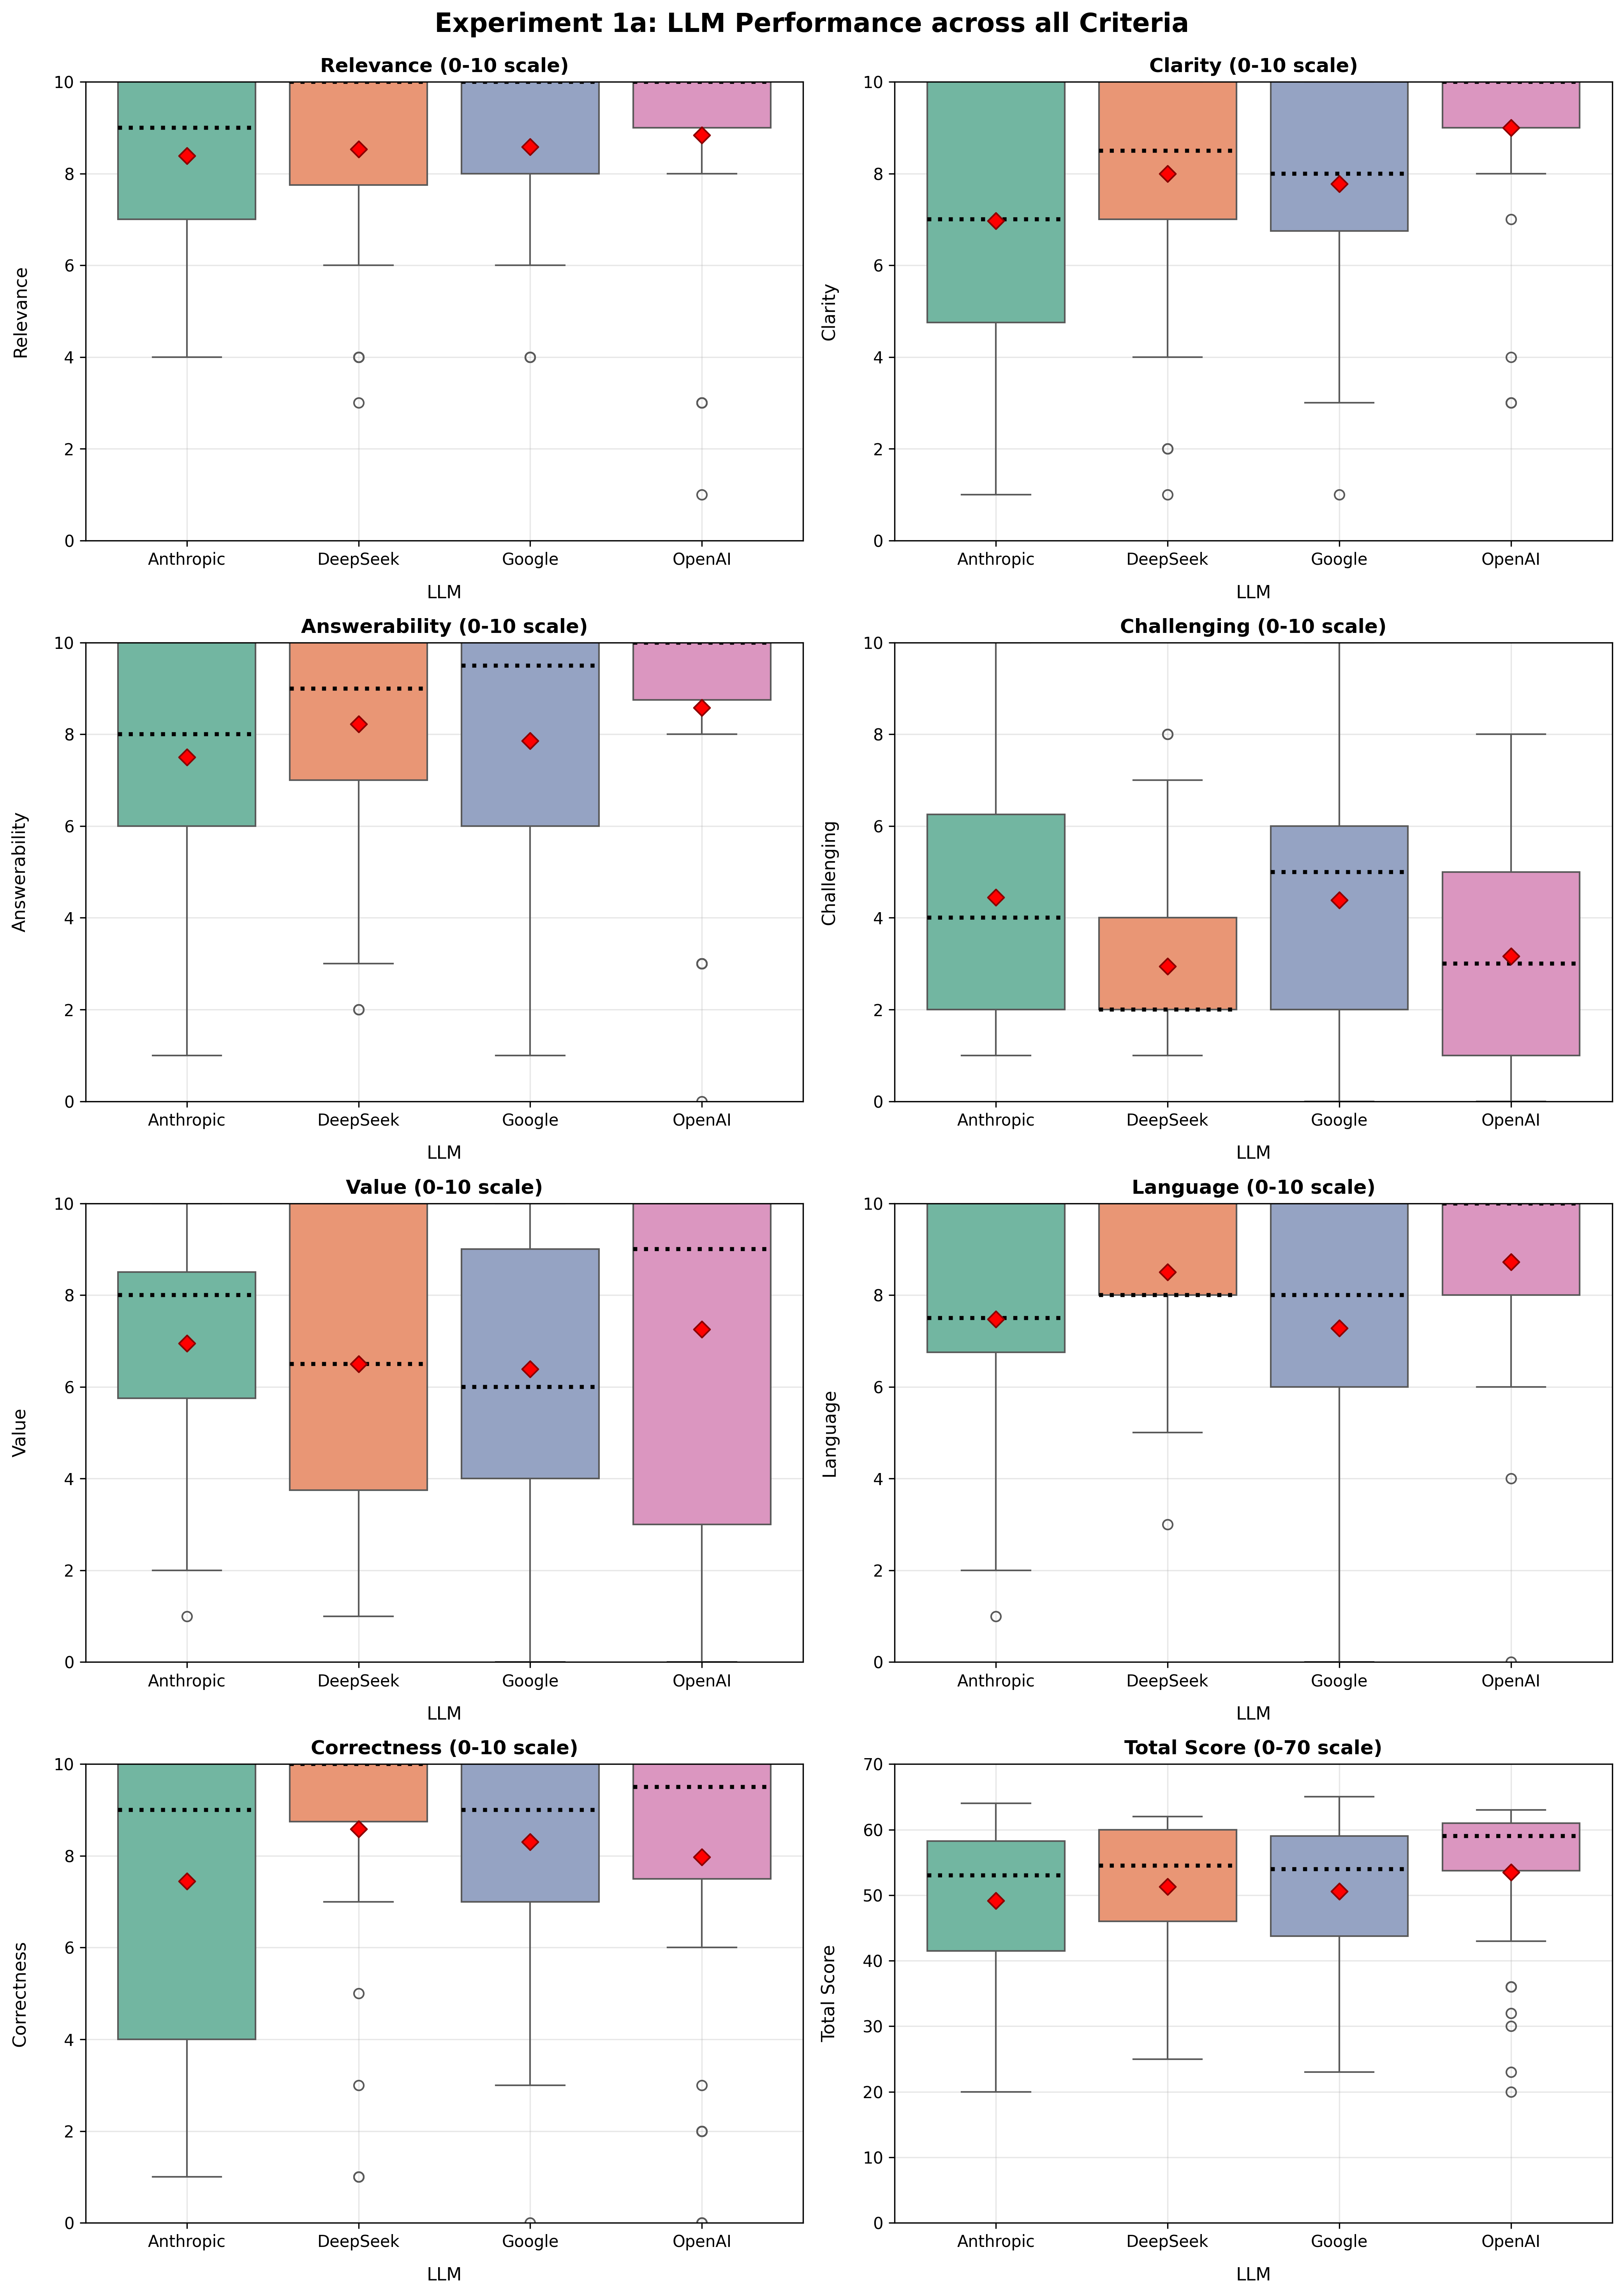


DETAILED STATISTICS - LLM PERFORMANCE (EXPERIMENT 1A)

Detailed Statistics by LLM (Experiment 1a):


relevance                            clarity                       \
               mean   std median min max count    mean   std median min max   
llm                                                                           
anthropic      8.39   1.9    9.0   4  10    36    6.97  2.76    7.0   1  10   
deepseek       8.53  2.24   10.0   3  10    36     8.0  2.51    8.5   1  10   
google         8.58  1.93   10.0   4  10    36    7.78   2.4    8.0   1  10   
openai         8.83  2.37   10.0   1  10    36     9.0   1.9   10.0   3  10   

                answerability                            challenging        \
          count          mean   std median min max count        mean   std   
llm                                                                          
anthropic    36           7.5   2.9    8.0   1  10    36        4.44  2.56   
deepseek     36          8.22  2.47    9.0   2  10    36        2.94  2.03   
google       36          7.86  2.83    9.5   1  10    36        4.39  2.41   
openai       36          8.58  2.64   10.0   0  10    36        3.17  2.13   

                               value                            language  \
          median min max count  mean   std median min max count     mean   
llm                                                                        
anthropic    4.0   1  10    36  6.94  2.67    8.0   1  10    36     7.47   
deepseek     2.0   1   8    36   6.5  2.95    6.5   1  10    36      8.5   
google       5.0   0  10    36  6.39  3.05    6.0   0  10    36     7.28   
openai       3.0   0   8    36  7.25  3.64    9.0   0  10    36     8.72   

                                     correctness                             \
            std median min max count        mean   std median min max count   
llm                                                                           
anthropic  2.46    7.5   1  10    36        7.44  3.03    9.0   1  10    36   
deepseek   1.63    8.0   3  10    36        8.58  2.43   10.0   1  10    36   
google      2.9    8.0   0  10    36        8.31  2.42    9.0   0  10    36   
openai     2.09   10.0   0  10    36        7.97  3.18    9.5   0  10    36   

          total_score                              
                 mean    std median min max count  
llm                                                
anthropic       49.17  11.98   53.0  20  64    36  
deepseek        51.28  10.61   54.5  25  62    36  
google          50.58  10.86   54.0  23  65    36  
openai          53.53   12.0   59.0  20  63    36


Mean Scores by LLM (Experiment 1a):


,relevance,clarity,answerability,challenging,value,language,correctness
llm,,,,,,,
anthropic,8.39,6.97,7.5,4.44,6.94,7.47,7.44
deepseek,8.53,8.0,8.22,2.94,6.5,8.5,8.58
google,8.58,7.78,7.86,4.39,6.39,7.28,8.31
openai,8.83,9.0,8.58,3.17,7.25,8.72,7.97



Overall LLM Ranking (Experiment 1a):
1. Openai: 7.65
2. Deepseek: 7.32
3. Google: 7.23
4. Anthropic: 7.02


In [20]:
fig, axes = plt.subplots(4, 2, figsize=(14, 20))
axes = axes.flatten()
plots['exp1a_llm_analysis'] = fig

criteria = ['relevance', 'clarity', 'answerability', 'challenging', 'value', 'language', 'correctness']

for i, criterion in enumerate(criteria):
    create_seaborn_boxplot(exp1a_df, 'llm', criterion, axes[i], 
                          f'{criterion.title()}', criterion.title(), 'LLM', scale_range=(0, 10))

create_seaborn_boxplot(exp1a_df, 'llm', 'total_score', axes[7], 
                      'Total Score', 'Total Score', 'LLM', scale_range=(0, 70))

plt.suptitle('Experiment 1a: LLM Performance across all Criteria', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

print("\n" + "="*80)
print("DETAILED STATISTICS - LLM PERFORMANCE (EXPERIMENT 1A)")
print("="*80)

all_criteria_with_total = criteria + ['total_score']
exp1a_llm_detailed_stats = exp1a_df.groupby('llm')[all_criteria_with_total].agg(['mean', 'std', 'median', 'min', 'max', 'count']).round(2)
tables['exp1a_llm_detailed_stats'] = exp1a_llm_detailed_stats
print("\nDetailed Statistics by LLM (Experiment 1a):")
display(exp1a_llm_detailed_stats)

exp1a_llm_means = exp1a_df.groupby('llm')[numeric_cols_1a].mean().round(2)
tables['exp1a_llm_means'] = exp1a_llm_means
print("\nMean Scores by LLM (Experiment 1a):")
display(exp1a_llm_means)

exp1a_llm_overall = exp1a_llm_means.mean(axis=1).sort_values(ascending=False)
tables['exp1a_llm_ranking'] = exp1a_llm_overall
print("\nOverall LLM Ranking (Experiment 1a):")
for i, (llm, score) in enumerate(exp1a_llm_overall.items(), 1):
    print(f"{i}. {llm.title()}: {score:.2f}")

## 1a.3: Analysis by Input Source

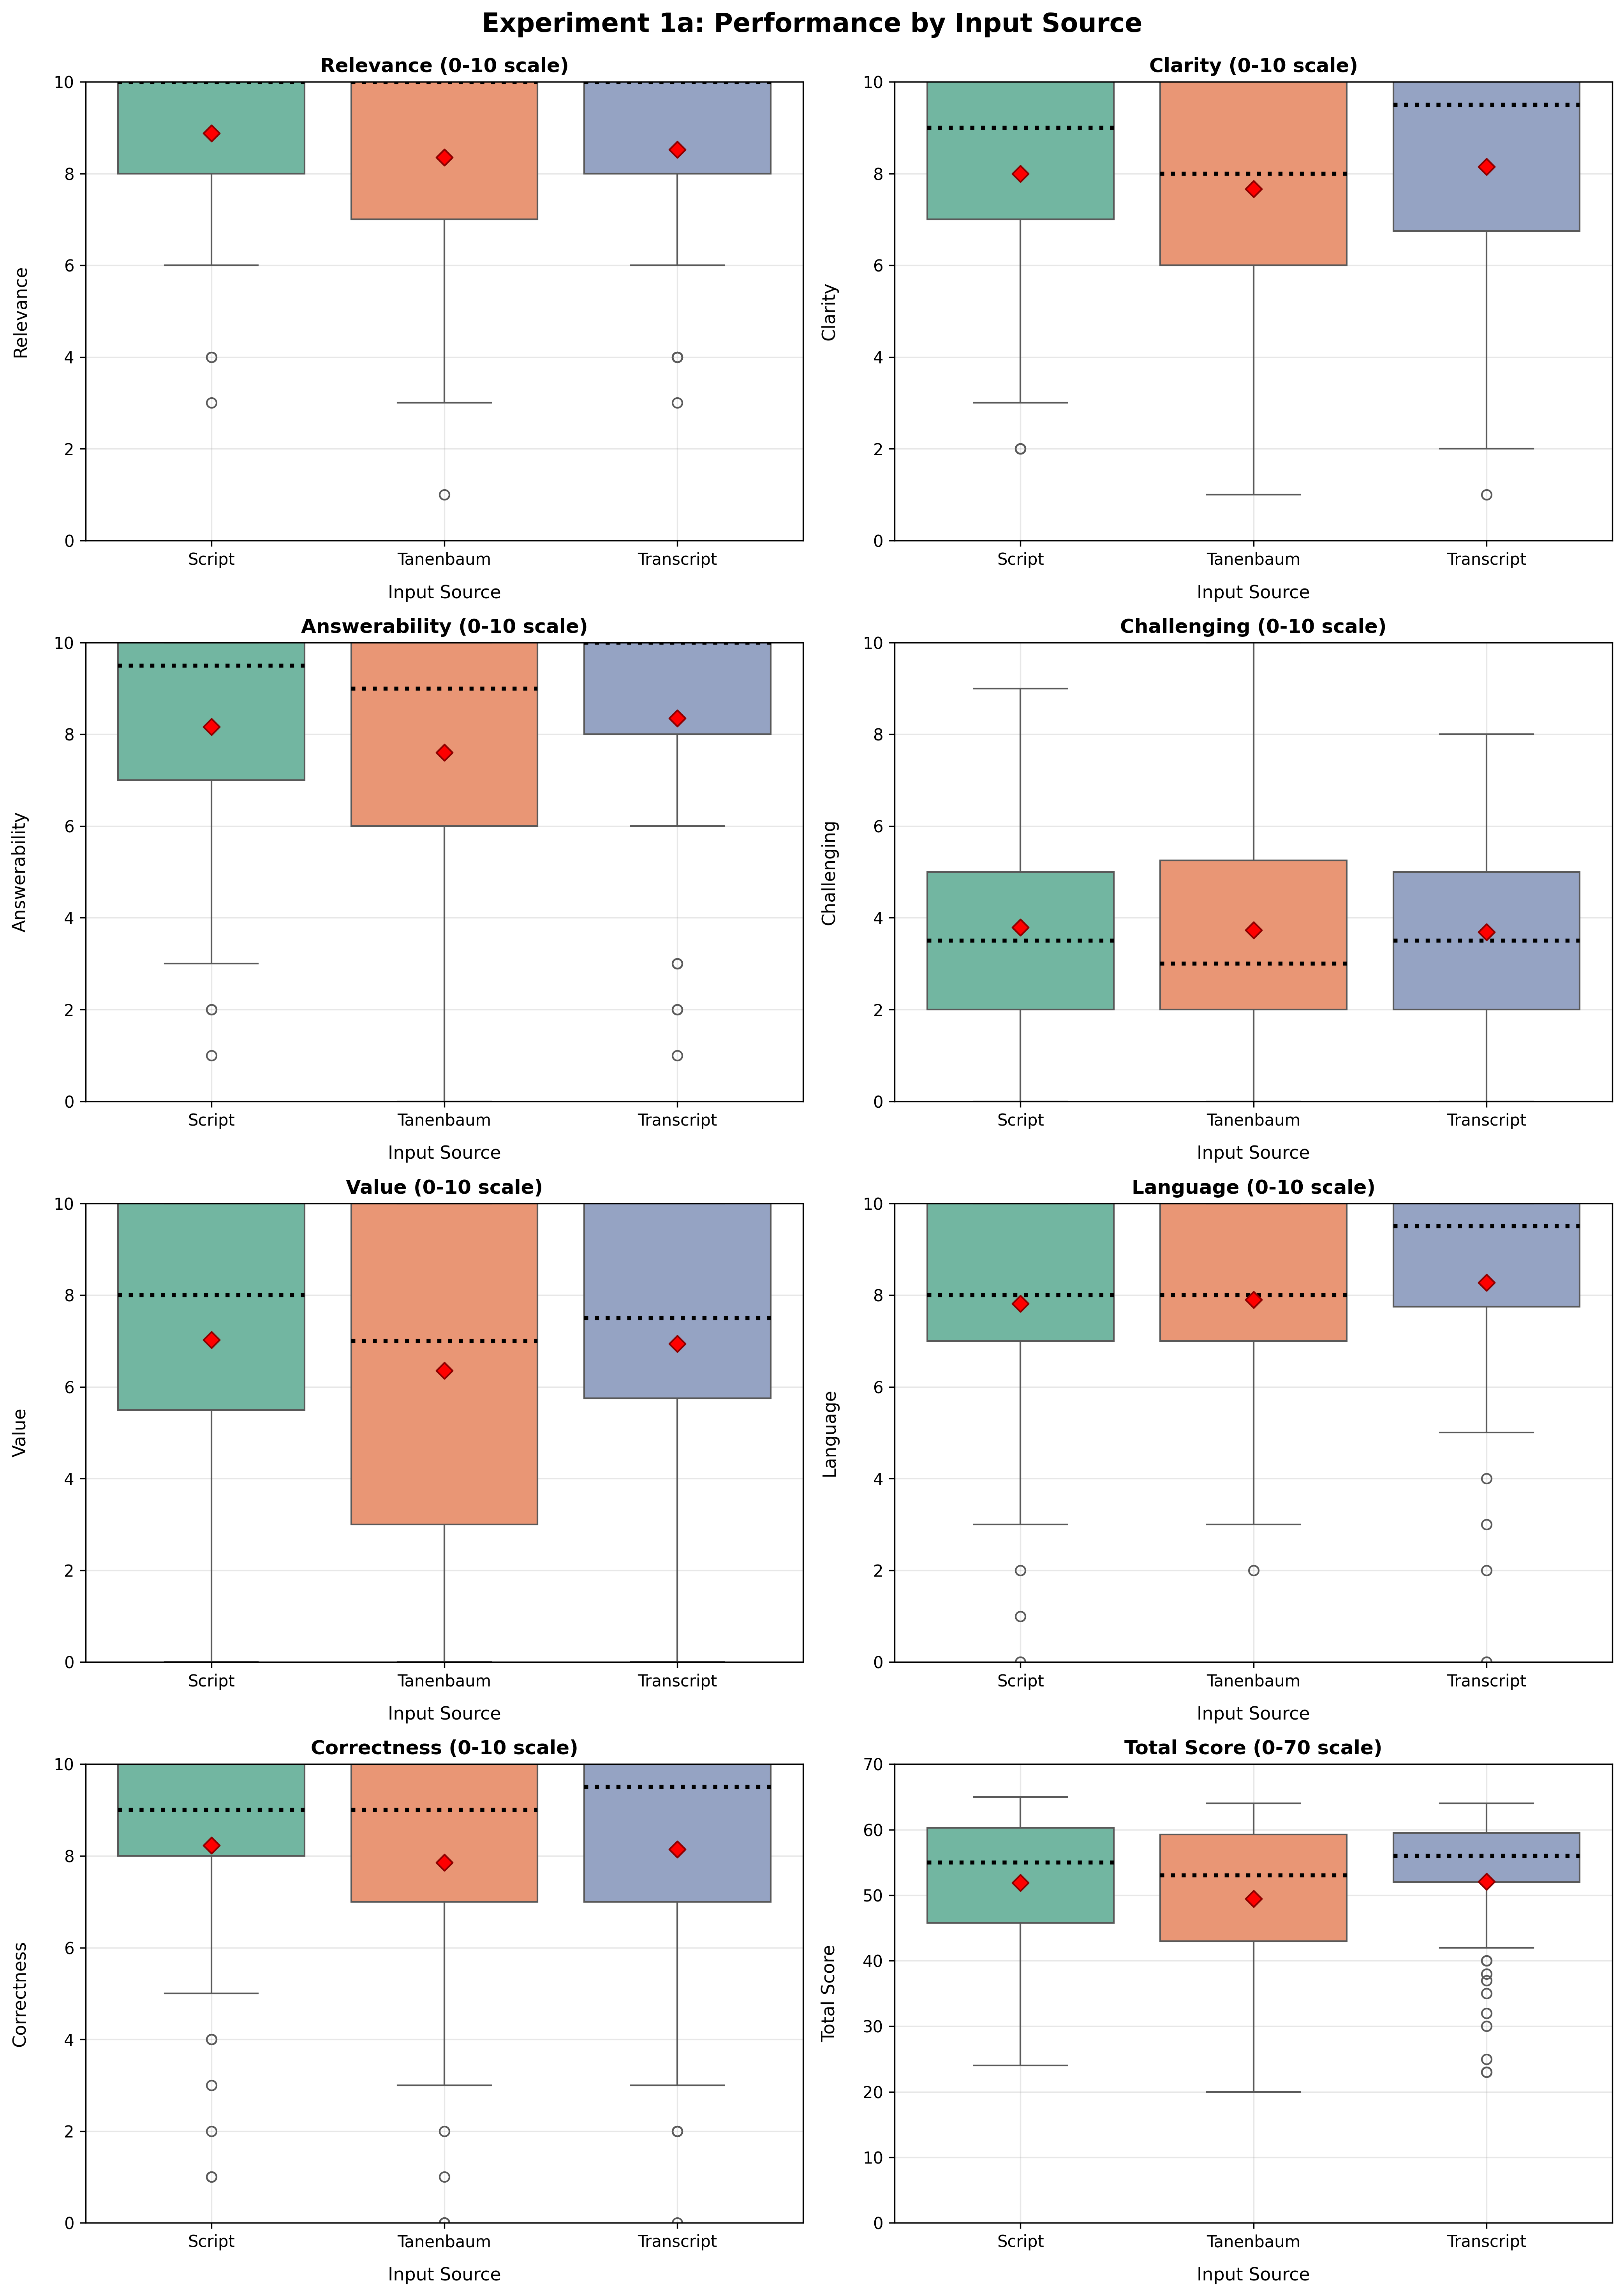


DETAILED STATISTICS - INPUT SOURCE PERFORMANCE (EXPERIMENT 1A)

Detailed Statistics by Input Source (Experiment 1a):


relevance                            clarity                   \
                  mean   std median min max count    mean   std median min   
input_source                                                                 
script            8.88  1.81   10.0   3  10    48     8.0  2.38    9.0   2   
tanenbaum         8.35  2.27   10.0   1  10    48    7.67  2.59    8.0   1   
transcript        8.52  2.21   10.0   3  10    48    8.15  2.54    9.5   1   

                       answerability                            challenging  \
             max count          mean   std median min max count        mean   
input_source                                                                  
script        10    48          8.17  2.61    9.5   1  10    48        3.79   
tanenbaum     10    48           7.6  3.06    9.0   0  10    48        3.73   
transcript    10    48          8.35  2.45   10.0   1  10    48        3.69   

                                        value                             \
               std median min max count  mean   std median min max count   
input_source                                                               
script        2.32    3.5   0   9    48  7.02  3.08    8.0   0  10    48   
tanenbaum     2.59    3.0   0  10    48  6.35  3.32    7.0   0  10    48   
transcript    2.23    3.5   0   8    48  6.94  2.85    7.5   0  10    48   

             language                            correctness                   \
                 mean   std median min max count        mean   std median min   
input_source                                                                    
script           7.81  2.52    8.0   0  10    48        8.23  2.55    9.0   1   
tanenbaum         7.9  2.27    8.0   2  10    48        7.85  3.01    9.0   0   
transcript       8.27  2.37    9.5   0  10    48        8.15  2.83    9.5   0   

                       total_score                              
             max count        mean    std median min max count  
input_source                                                    
script        10    48        51.9  11.15   55.0  24  65    48  
tanenbaum     10    48       49.46  11.66   53.0  20  64    48  
transcript    10    48       52.06  11.36   56.0  23  64    48


Mean Scores by Input Source (Experiment 1a):


,relevance,clarity,answerability,challenging,value,language,correctness
input_source,,,,,,,
script,8.88,8.0,8.17,3.79,7.02,7.81,8.23
tanenbaum,8.35,7.67,7.6,3.73,6.35,7.9,7.85
transcript,8.52,8.15,8.35,3.69,6.94,8.27,8.15



Input Source Ranking by Total Score (Experiment 1a):
1. Transcript: 52.06/70
2. Script: 51.90/70
3. Tanenbaum: 49.46/70


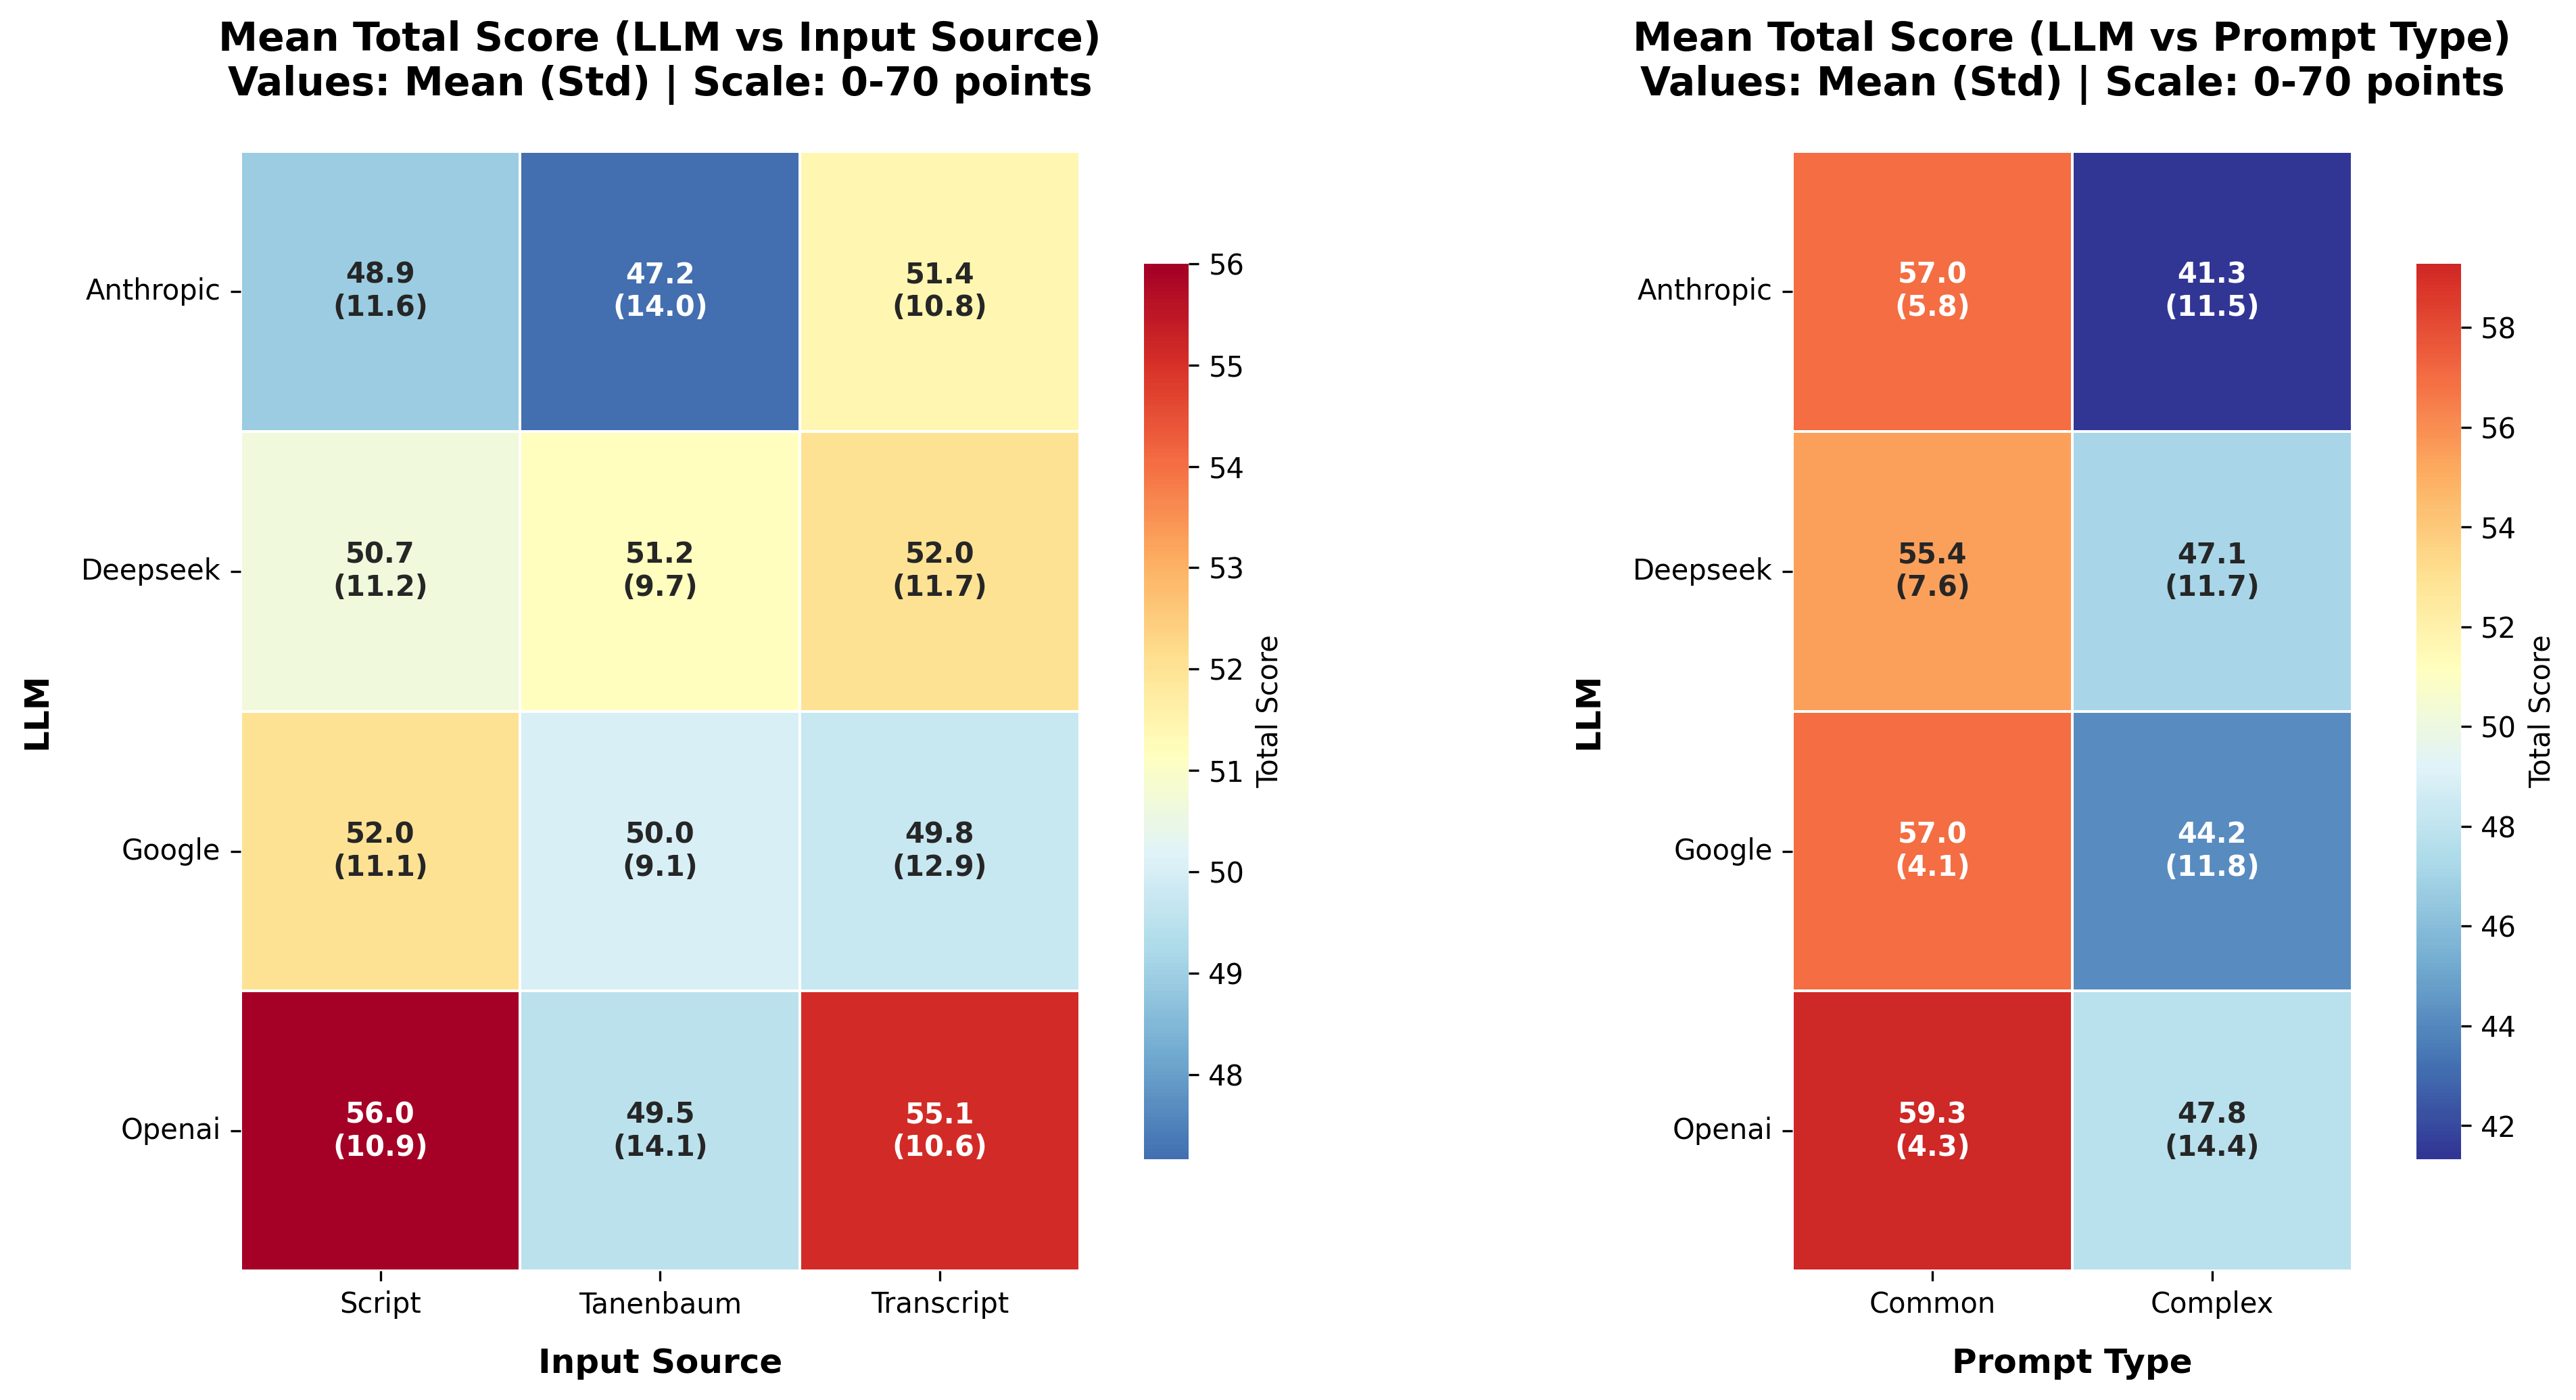


DETAILED STATISTICS - LLM vs INPUT SOURCE COMBINATIONS (EXPERIMENT 1A)

Detailed Statistics for LLM vs Input Source Combinations (Experiment 1a):


mean    std  median  min  max  count
llm       input_source                                       
anthropic script        48.92  11.59    52.5   24   64     12
          tanenbaum     47.17  13.97    47.5   20   64     12
          transcript    51.42  10.84    54.5   35   64     12
deepseek  script        50.67  11.18    54.5   26   62     12
          tanenbaum     51.17   9.73    52.5   35   62     12
          transcript     52.0  11.73    56.0   25   62     12
google    script         52.0  11.09    55.0   29   65     12
          tanenbaum      50.0   9.06    53.0   28   60     12
          transcript    49.75  12.93    55.0   23   61     12
openai    script         56.0  10.91    60.0   30   63     12
          tanenbaum      49.5  14.13    55.0   20   63     12
          transcript    55.08  10.61    57.0   23   63     12


DETAILED STATISTICS - LLM vs PROMPT TYPE COMBINATIONS (EXPERIMENT 1A)

Detailed Statistics for LLM vs Prompt Type Combinations (Experiment 1a):


mean    std  median  min  max  count
llm       prompt_type                                       
anthropic common        57.0   5.79    57.5   44   64     18
          complex      41.33   11.5    41.0   20   64     18
deepseek  common       55.44   7.57    58.0   35   62     18
          complex      47.11  11.74    48.5   25   62     18
google    common        57.0   4.06    57.0   46   62     18
          complex      44.17   11.8    43.5   23   65     18
openai    common       59.28   4.31    61.0   46   63     18
          complex      47.78  14.42    54.5   20   63     18

In [21]:
fig, axes = plt.subplots(4, 2, figsize=(14, 20))
axes = axes.flatten()
plots['exp1a_source_analysis'] = fig

for i, criterion in enumerate(criteria):
    create_seaborn_boxplot(exp1a_df, 'input_source', criterion, axes[i], 
                          f'{criterion.title()}', criterion.title(), 'Input Source', scale_range=(0, 10))

create_seaborn_boxplot(exp1a_df, 'input_source', 'total_score', axes[7], 
                      'Total Score', 'Total Score', 'Input Source', scale_range=(0, 70))

plt.suptitle('Experiment 1a: Performance by Input Source', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

print("\n" + "="*80)
print("DETAILED STATISTICS - INPUT SOURCE PERFORMANCE (EXPERIMENT 1A)")
print("="*80)

exp1a_source_detailed_stats = exp1a_df.groupby('input_source')[all_criteria_with_total].agg(['mean', 'std', 'median', 'min', 'max', 'count']).round(2)
tables['exp1a_source_detailed_stats'] = exp1a_source_detailed_stats
print("\nDetailed Statistics by Input Source (Experiment 1a):")
display(exp1a_source_detailed_stats)

exp1a_source_means = exp1a_df.groupby('input_source')[numeric_cols_1a].mean().round(2)
tables['exp1a_source_means'] = exp1a_source_means
print("\nMean Scores by Input Source (Experiment 1a):")
display(exp1a_source_means)

exp1a_source_overall = exp1a_df.groupby('input_source')['total_score'].mean().sort_values(ascending=False)
tables['exp1a_source_ranking'] = exp1a_source_overall
print("\nInput Source Ranking by Total Score (Experiment 1a):")
for i, (source, score) in enumerate(exp1a_source_overall.items(), 1):
    print(f"{i}. {source.title()}: {score:.2f}/70")

# Total Score Paired Heatmaps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
plots['exp1a_total_score_paired_heatmaps'] = fig

# Heatmap 1: Total Score by Input Source vs LLM
heatmap_mean = exp1a_df.groupby(['llm', 'input_source'])['total_score'].mean().unstack()
heatmap_std = exp1a_df.groupby(['llm', 'input_source'])['total_score'].std().unstack()

# Konvertiere zu float für seaborn-Kompatibilität
heatmap_mean = heatmap_mean.astype(float)
heatmap_std = heatmap_std.astype(float)

# Erstelle String-Matrix für Annotationen
annot_matrix = pd.DataFrame(index=heatmap_mean.index, columns=heatmap_mean.columns, dtype=str)
for i in range(len(heatmap_mean.index)):
    for j in range(len(heatmap_mean.columns)):
        mean_val = heatmap_mean.iloc[i, j]
        std_val = heatmap_std.iloc[i, j]
        if pd.notna(mean_val) and pd.notna(std_val):
            annot_matrix.iloc[i, j] = f"{mean_val:.1f}\n({std_val:.1f})"
        elif pd.notna(mean_val):
            annot_matrix.iloc[i, j] = f"{mean_val:.1f}"
        else:
            annot_matrix.iloc[i, j] = ""

llm_labels = [label.title() for label in heatmap_mean.index]
source_labels = [label.title() for label in heatmap_mean.columns]

sns.heatmap(heatmap_mean, 
            annot=annot_matrix, 
            fmt='', 
            cmap='RdYlBu_r',
            center=heatmap_mean.mean().mean(),
            square=True,
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Total Score'},
            annot_kws={'size': 10, 'weight': 'bold'},
            xticklabels=source_labels, 
            yticklabels=llm_labels, 
            ax=ax1)

ax1.set_title('Mean Total Score (LLM vs Input Source)\nValues: Mean (Std) | Scale: 0-70 points', 
             fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel('Input Source', fontsize=12, fontweight='bold', labelpad=10)
ax1.set_ylabel('LLM', fontsize=12, fontweight='bold', labelpad=10)

ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0, ha='center')
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0)

# Heatmap 2: Total Score by Prompt Type vs LLM
heatmap_mean_prompt = exp1a_df.groupby(['llm', 'prompt_type'])['total_score'].mean().unstack()
heatmap_std_prompt = exp1a_df.groupby(['llm', 'prompt_type'])['total_score'].std().unstack()

# Konvertiere zu float für seaborn-Kompatibilität
heatmap_mean_prompt = heatmap_mean_prompt.astype(float)
heatmap_std_prompt = heatmap_std_prompt.astype(float)

# Erstelle String-Matrix für Annotationen
annot_matrix_prompt = pd.DataFrame(index=heatmap_mean_prompt.index, columns=heatmap_mean_prompt.columns, dtype=str)
for i in range(len(heatmap_mean_prompt.index)):
    for j in range(len(heatmap_mean_prompt.columns)):
        mean_val = heatmap_mean_prompt.iloc[i, j]
        std_val = heatmap_std_prompt.iloc[i, j]
        if pd.notna(mean_val) and pd.notna(std_val):
            annot_matrix_prompt.iloc[i, j] = f"{mean_val:.1f}\n({std_val:.1f})"
        elif pd.notna(mean_val):
            annot_matrix_prompt.iloc[i, j] = f"{mean_val:.1f}"
        else:
            annot_matrix_prompt.iloc[i, j] = ""

llm_labels = [label.title() for label in heatmap_mean_prompt.index]
prompt_labels = [label.title() for label in heatmap_mean_prompt.columns]

sns.heatmap(heatmap_mean_prompt, 
            annot=annot_matrix_prompt, 
            fmt='', 
            cmap='RdYlBu_r',
            center=heatmap_mean_prompt.mean().mean(),
            square=True,
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Total Score'},
            annot_kws={'size': 10, 'weight': 'bold'},
            xticklabels=prompt_labels, 
            yticklabels=llm_labels, 
            ax=ax2)

ax2.set_title('Mean Total Score (LLM vs Prompt Type)\nValues: Mean (Std) | Scale: 0-70 points', 
             fontsize=14, fontweight='bold', pad=20)
ax2.set_xlabel('Prompt Type', fontsize=12, fontweight='bold', labelpad=10)
ax2.set_ylabel('LLM', fontsize=12, fontweight='bold', labelpad=10)

ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0, ha='center')
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("DETAILED STATISTICS - LLM vs INPUT SOURCE COMBINATIONS (EXPERIMENT 1A)")
print("="*80)

exp1a_llm_source_combinations = exp1a_df.groupby(['llm', 'input_source'])['total_score'].agg(['mean', 'std', 'median', 'min', 'max', 'count']).round(2)
tables['exp1a_llm_source_combinations'] = exp1a_llm_source_combinations
print("\nDetailed Statistics for LLM vs Input Source Combinations (Experiment 1a):")
display(exp1a_llm_source_combinations)

print("\n" + "="*80)
print("DETAILED STATISTICS - LLM vs PROMPT TYPE COMBINATIONS (EXPERIMENT 1A)")
print("="*80)

exp1a_llm_prompt_combinations = exp1a_df.groupby(['llm', 'prompt_type'])['total_score'].agg(['mean', 'std', 'median', 'min', 'max', 'count']).round(2)
tables['exp1a_llm_prompt_combinations'] = exp1a_llm_prompt_combinations
print("\nDetailed Statistics for LLM vs Prompt Type Combinations (Experiment 1a):")
display(exp1a_llm_prompt_combinations)

## 1a.4: Analysis by Prompt Type

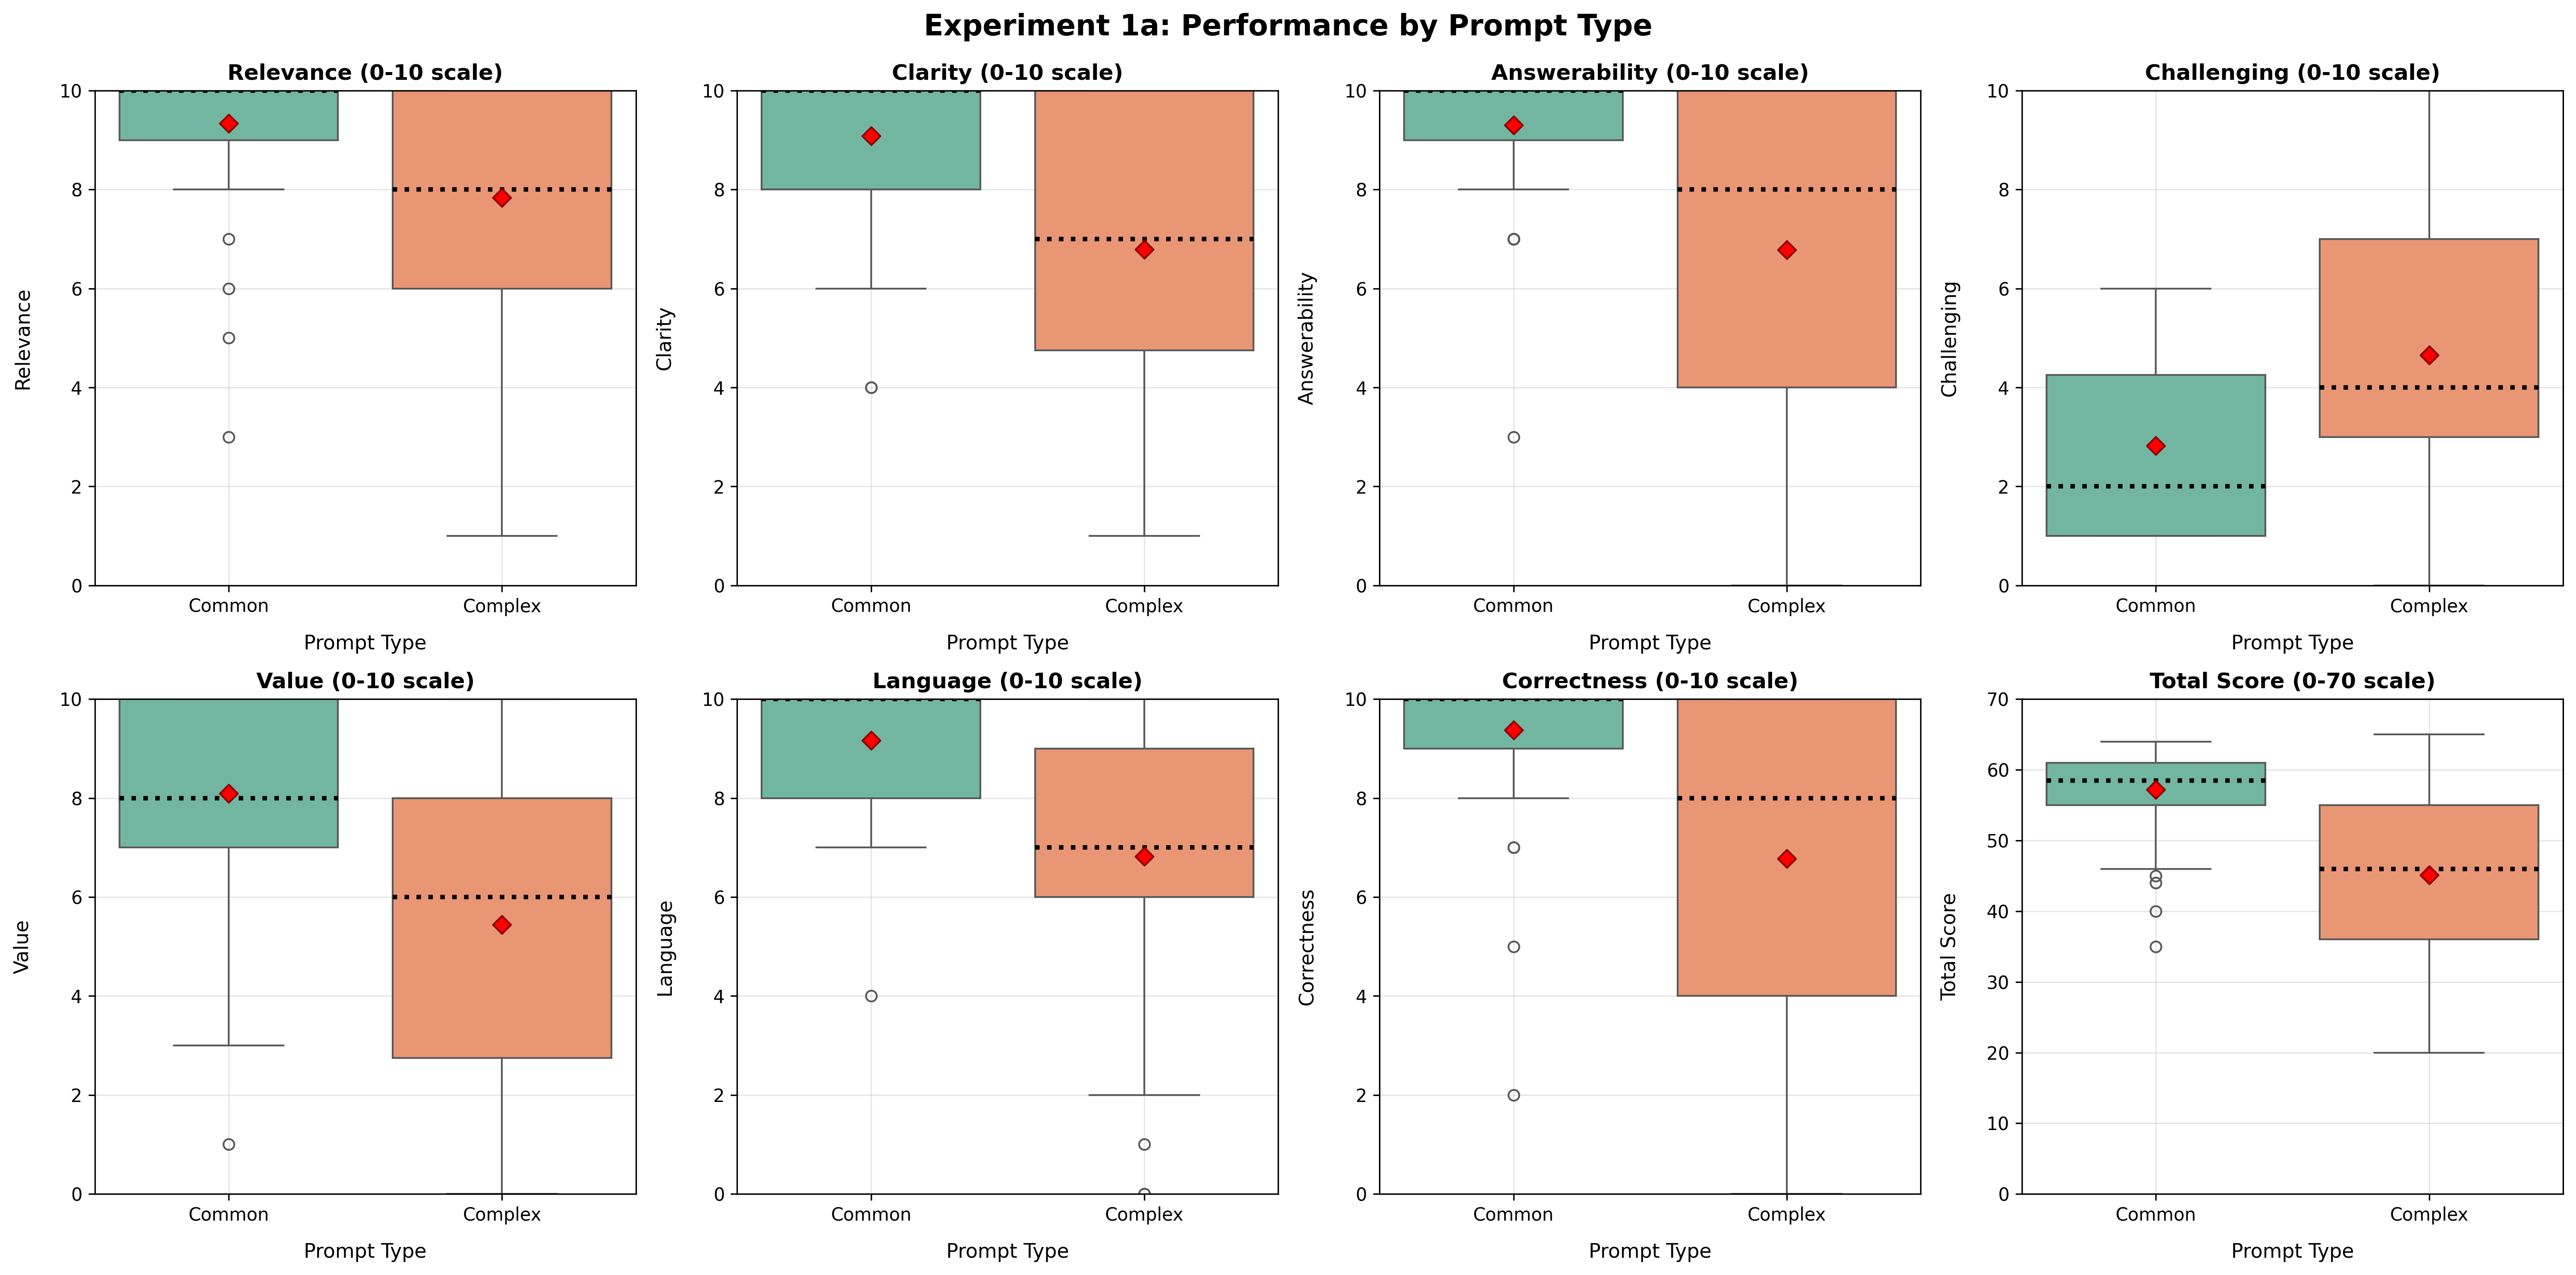


DETAILED STATISTICS - PROMPT TYPE PERFORMANCE (EXPERIMENT 1A)

Detailed Statistics by Prompt Type (Experiment 1a):


relevance                            clarity                       \
                 mean   std median min max count    mean   std median min max   
prompt_type                                                                     
common           9.33  1.27   10.0   3  10    72    9.08   1.4   10.0   4  10   
complex          7.83  2.48    8.0   1  10    72    6.79  2.81    7.0   1  10   

                  answerability                            challenging        \
            count          mean   std median min max count        mean   std   
prompt_type                                                                    
common         72          9.31  1.21   10.0   3  10    72        2.82  1.73   
complex        72          6.78  3.19    8.0   0  10    72        4.65  2.57   

                                 value                            language  \
            median min max count  mean   std median min max count     mean   
prompt_type                                                                  
common         2.0   1   6    72   8.1  2.29    8.0   1  10    72     9.17   
complex        4.0   0  10    72  5.44  3.22    6.0   0  10    72     6.82   

                                       correctness                             \
              std median min max count        mean   std median min max count   
prompt_type                                                                     
common        1.2   10.0   4  10    72        9.38  1.23   10.0   2  10    72   
complex      2.68    7.0   0  10    72        6.78  3.28    8.0   0  10    72   

            total_score                              
                   mean    std median min max count  
prompt_type                                          
common            57.18   5.66   58.5  35  64    72  
complex            45.1  12.43   46.0  20  65    72


Mean Scores by Prompt Type (Experiment 1a):


,relevance,clarity,answerability,challenging,value,language,correctness
prompt_type,,,,,,,
common,9.33,9.08,9.31,2.82,8.1,9.17,9.38
complex,7.83,6.79,6.78,4.65,5.44,6.82,6.78



Complex vs Common Prompt Difference (Experiment 1a):
  Relevance: -1.50 (lower for complex)
  Clarity: -2.29 (lower for complex)
  Answerability: -2.53 (lower for complex)
  Challenging: +1.83 (higher for complex)
  Value: -2.66 (lower for complex)
  Language: -2.35 (lower for complex)
  Correctness: -2.60 (lower for complex)

DETAILED STATISTICS - LLM vs PROMPT TYPE COMBINATIONS (EXPERIMENT 1A)

Detailed Statistics for LLM vs Prompt Type Combinations (Experiment 1a):


mean    std  median  min  max  count
llm       prompt_type                                       
anthropic common        57.0   5.79    57.5   44   64     18
          complex      41.33   11.5    41.0   20   64     18
deepseek  common       55.44   7.57    58.0   35   62     18
          complex      47.11  11.74    48.5   25   62     18
google    common        57.0   4.06    57.0   46   62     18
          complex      44.17   11.8    43.5   23   65     18
openai    common       59.28   4.31    61.0   46   63     18
          complex      47.78  14.42    54.5   20   63     18

In [22]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
plots['exp1a_prompt_analysis'] = fig

for i, criterion in enumerate(criteria):
    create_seaborn_boxplot(exp1a_df, 'prompt_type', criterion, axes[i], 
                          f'{criterion.title()}', criterion.title(), 'Prompt Type', scale_range=(0, 10))

create_seaborn_boxplot(exp1a_df, 'prompt_type', 'total_score', axes[7], 
                      'Total Score', 'Total Score', 'Prompt Type', scale_range=(0, 70))

plt.suptitle('Experiment 1a: Performance by Prompt Type', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

print("\n" + "="*80)
print("DETAILED STATISTICS - PROMPT TYPE PERFORMANCE (EXPERIMENT 1A)")
print("="*80)

exp1a_prompt_detailed_stats = exp1a_df.groupby('prompt_type')[all_criteria_with_total].agg(['mean', 'std', 'median', 'min', 'max', 'count']).round(2)
tables['exp1a_prompt_detailed_stats'] = exp1a_prompt_detailed_stats
print("\nDetailed Statistics by Prompt Type (Experiment 1a):")
display(exp1a_prompt_detailed_stats)

exp1a_prompt_means = exp1a_df.groupby('prompt_type')[numeric_cols_1a].mean().round(2)
tables['exp1a_prompt_means'] = exp1a_prompt_means
print("\nMean Scores by Prompt Type (Experiment 1a):")
display(exp1a_prompt_means)

prompt_diff = exp1a_prompt_means.loc['complex'] - exp1a_prompt_means.loc['common']
print("\nComplex vs Common Prompt Difference (Experiment 1a):")
for criterion, diff in prompt_diff.items():
    direction = "higher" if diff > 0 else "lower"
    print(f"  {criterion.title()}: {diff:+.2f} ({direction} for complex)")

print("\n" + "="*80)
print("DETAILED STATISTICS - LLM vs PROMPT TYPE COMBINATIONS (EXPERIMENT 1A)")
print("="*80)

exp1a_llm_prompt_combinations = exp1a_df.groupby(['llm', 'prompt_type'])['total_score'].agg(['mean', 'std', 'median', 'min', 'max', 'count']).round(2)
tables['exp1a_llm_prompt_combinations'] = exp1a_llm_prompt_combinations
print("\nDetailed Statistics for LLM vs Prompt Type Combinations (Experiment 1a):")
display(exp1a_llm_prompt_combinations)


CORRECTNESS ANALYSIS - PAIRED HEATMAPS


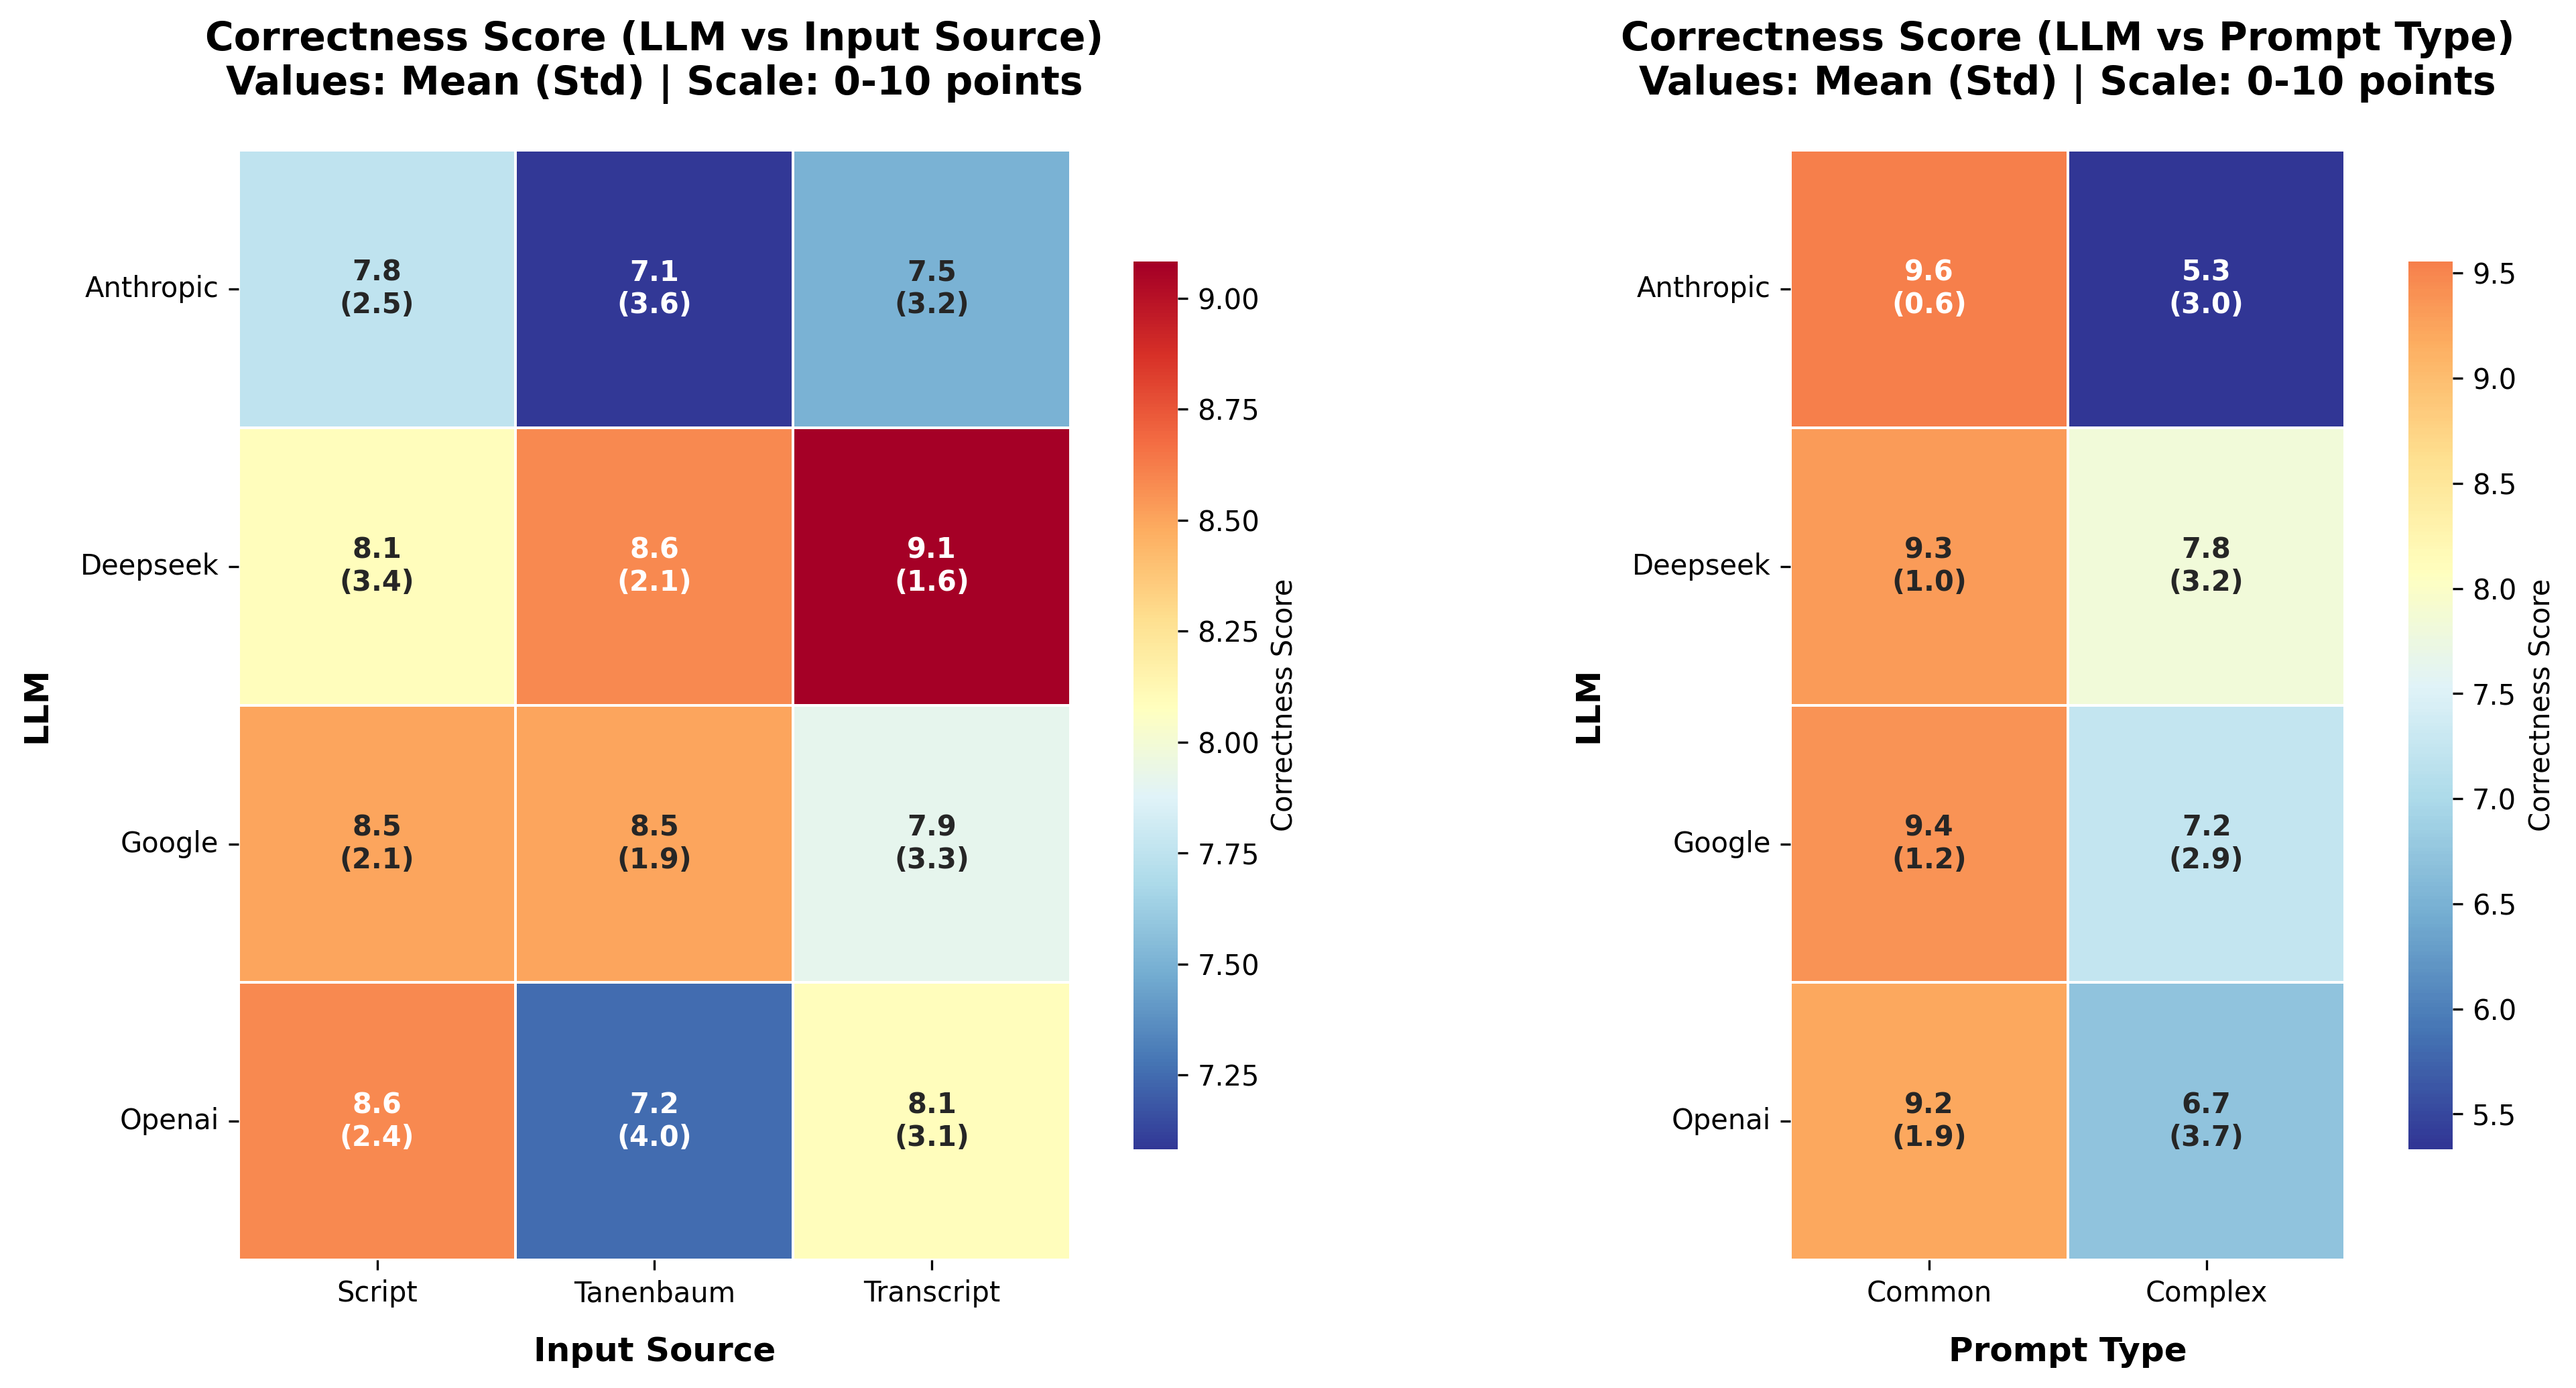


Detailed Correctness Statistics by LLM and Input Source:


mean   std  median  min  max  count
llm       input_source                                     
anthropic script        7.75  2.45     8.0    3   10     12
          tanenbaum     7.08  3.55     9.0    1   10     12
          transcript     7.5  3.21     9.0    2   10     12
deepseek  script        8.08  3.37     9.5    1   10     12
          tanenbaum     8.58  2.11     9.5    3   10     12
          transcript    9.08  1.56    10.0    5   10     12
google    script         8.5  2.07     9.5    4   10     12
          tanenbaum      8.5  1.88     9.0    5   10     12
          transcript    7.92  3.26     9.5    0   10     12
openai    script        8.58  2.39     9.5    2   10     12
          tanenbaum     7.25   4.0     9.5    0   10     12
          transcript    8.08  3.06     9.5    2   10     12


Detailed Correctness Statistics by LLM and Prompt Type:


mean   std  median  min  max  count
llm       prompt_type                                     
anthropic common       9.56  0.62    10.0    8   10     18
          complex      5.33  3.01     4.0    1   10     18
deepseek  common       9.33  0.97    10.0    7   10     18
          complex      7.83  3.17     9.5    1   10     18
google    common       9.39   1.2    10.0    5   10     18
          complex      7.22  2.86     7.5    0   10     18
openai    common       9.22  1.86    10.0    2   10     18
          complex      6.72  3.74     8.5    0   10     18

In [23]:
# Correctness-focused Heatmaps

print("\n" + "="*80)
print("CORRECTNESS ANALYSIS - PAIRED HEATMAPS")
print("="*80)

# Paired Heatmaps: Correctness by Input Source vs LLM and Prompt Type vs LLM
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
plots['exp1a_correctness_paired_heatmaps'] = fig

# Heatmap 1: Correctness by Input Source vs LLM
correctness_heatmap_mean = exp1a_df.groupby(['llm', 'input_source'])['correctness'].mean().unstack()
correctness_heatmap_std = exp1a_df.groupby(['llm', 'input_source'])['correctness'].std().unstack()

# Konvertiere zu float für seaborn-Kompatibilität
correctness_heatmap_mean = correctness_heatmap_mean.astype(float)
correctness_heatmap_std = correctness_heatmap_std.astype(float)

# Erstelle String-Matrix für Annotationen
correctness_annot_matrix = pd.DataFrame(index=correctness_heatmap_mean.index, columns=correctness_heatmap_mean.columns, dtype=str)
for i in range(len(correctness_heatmap_mean.index)):
    for j in range(len(correctness_heatmap_mean.columns)):
        mean_val = correctness_heatmap_mean.iloc[i, j]
        std_val = correctness_heatmap_std.iloc[i, j]
        if pd.notna(mean_val) and pd.notna(std_val):
            correctness_annot_matrix.iloc[i, j] = f"{mean_val:.1f}\n({std_val:.1f})"
        elif pd.notna(mean_val):
            correctness_annot_matrix.iloc[i, j] = f"{mean_val:.1f}"
        else:
            correctness_annot_matrix.iloc[i, j] = ""

llm_labels = [label.title() for label in correctness_heatmap_mean.index]
source_labels = [label.title() for label in correctness_heatmap_mean.columns]

sns.heatmap(correctness_heatmap_mean, 
            annot=correctness_annot_matrix, 
            fmt='', 
            cmap='RdYlBu_r',
            center=correctness_heatmap_mean.mean().mean(),
            square=True,
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Correctness Score'},
            annot_kws={'size': 10, 'weight': 'bold'},
            xticklabels=source_labels, 
            yticklabels=llm_labels, 
            ax=ax1)

ax1.set_title('Correctness Score (LLM vs Input Source)\nValues: Mean (Std) | Scale: 0-10 points', 
             fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel('Input Source', fontsize=12, fontweight='bold', labelpad=10)
ax1.set_ylabel('LLM', fontsize=12, fontweight='bold', labelpad=10)

ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0, ha='center')
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0)

# Heatmap 2: Correctness by Prompt Type vs LLM
correctness_prompt_heatmap_mean = exp1a_df.groupby(['llm', 'prompt_type'])['correctness'].mean().unstack()
correctness_prompt_heatmap_std = exp1a_df.groupby(['llm', 'prompt_type'])['correctness'].std().unstack()

# Konvertiere zu float für seaborn-Kompatibilität
correctness_prompt_heatmap_mean = correctness_prompt_heatmap_mean.astype(float)
correctness_prompt_heatmap_std = correctness_prompt_heatmap_std.astype(float)

# Erstelle String-Matrix für Annotationen
correctness_prompt_annot_matrix = pd.DataFrame(index=correctness_prompt_heatmap_mean.index, columns=correctness_prompt_heatmap_mean.columns, dtype=str)
for i in range(len(correctness_prompt_heatmap_mean.index)):
    for j in range(len(correctness_prompt_heatmap_mean.columns)):
        mean_val = correctness_prompt_heatmap_mean.iloc[i, j]
        std_val = correctness_prompt_heatmap_std.iloc[i, j]
        if pd.notna(mean_val) and pd.notna(std_val):
            correctness_prompt_annot_matrix.iloc[i, j] = f"{mean_val:.1f}\n({std_val:.1f})"
        elif pd.notna(mean_val):
            correctness_prompt_annot_matrix.iloc[i, j] = f"{mean_val:.1f}"
        else:
            correctness_prompt_annot_matrix.iloc[i, j] = ""

llm_labels = [label.title() for label in correctness_prompt_heatmap_mean.index]
prompt_labels = [label.title() for label in correctness_prompt_heatmap_mean.columns]

sns.heatmap(correctness_prompt_heatmap_mean, 
            annot=correctness_prompt_annot_matrix, 
            fmt='', 
            cmap='RdYlBu_r',
            center=correctness_prompt_heatmap_mean.mean().mean(),
            square=True,
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Correctness Score'},
            annot_kws={'size': 10, 'weight': 'bold'},
            xticklabels=prompt_labels, 
            yticklabels=llm_labels, 
            ax=ax2)

ax2.set_title('Correctness Score (LLM vs Prompt Type)\nValues: Mean (Std) | Scale: 0-10 points', 
             fontsize=14, fontweight='bold', pad=20)
ax2.set_xlabel('Prompt Type', fontsize=12, fontweight='bold', labelpad=10)
ax2.set_ylabel('LLM', fontsize=12, fontweight='bold', labelpad=10)

ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0, ha='center')
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

# Statistics for both heatmaps
correctness_llm_source_stats = exp1a_df.groupby(['llm', 'input_source'])['correctness'].agg(['mean', 'std', 'median', 'min', 'max', 'count']).round(2)
tables['exp1a_correctness_llm_source_stats'] = correctness_llm_source_stats
print("\nDetailed Correctness Statistics by LLM and Input Source:")
display(correctness_llm_source_stats)

correctness_llm_prompt_stats = exp1a_df.groupby(['llm', 'prompt_type'])['correctness'].agg(['mean', 'std', 'median', 'min', 'max', 'count']).round(2)
tables['exp1a_correctness_llm_prompt_stats'] = correctness_llm_prompt_stats
print("\nDetailed Correctness Statistics by LLM and Prompt Type:")
display(correctness_llm_prompt_stats)

In [24]:
print("\n" + "="*80)
print("CORRECTNESS INSIGHTS")
print("="*80)

# Best LLM for correctness
correctness_by_llm = exp1a_df.groupby('llm')['correctness'].mean().sort_values(ascending=False)
print(f"\nCorrectness Ranking by LLM:")
for i, (llm, score) in enumerate(correctness_by_llm.items(), 1):
    print(f"{i}. {llm.title()}: {score:.2f}")

# Best input source for correctness
correctness_by_source = exp1a_df.groupby('input_source')['correctness'].mean().sort_values(ascending=False)
print(f"\nCorrectness Ranking by Input Source:")
for i, (source, score) in enumerate(correctness_by_source.items(), 1):
    print(f"{i}. {source.title()}: {score:.2f}")

# Best prompt type for correctness
correctness_by_prompt = exp1a_df.groupby('prompt_type')['correctness'].mean().sort_values(ascending=False)
print(f"\nCorrectness Ranking by Prompt Type:")
for i, (prompt, score) in enumerate(correctness_by_prompt.items(), 1):
    print(f"{i}. {prompt.title()}: {score:.2f}")

# Identify best combinations
best_llm_source = exp1a_df.groupby(['llm', 'input_source'])['correctness'].mean().idxmax()
best_llm_source_score = exp1a_df.groupby(['llm', 'input_source'])['correctness'].mean().max()
print(f"\nBest LLM-Source combination for correctness:")
print(f"  {best_llm_source[0].title()} + {best_llm_source[1].title()}: {best_llm_source_score:.2f}")

best_llm_prompt = exp1a_df.groupby(['llm', 'prompt_type'])['correctness'].mean().idxmax()
best_llm_prompt_score = exp1a_df.groupby(['llm', 'prompt_type'])['correctness'].mean().max()
print(f"\nBest LLM-Prompt combination for correctness:")
print(f"  {best_llm_prompt[0].title()} + {best_llm_prompt[1].title()}: {best_llm_prompt_score:.2f}")


CORRECTNESS INSIGHTS

Correctness Ranking by LLM:
1. Deepseek: 8.58
2. Google: 8.31
3. Openai: 7.97
4. Anthropic: 7.44

Correctness Ranking by Input Source:
1. Script: 8.23
2. Transcript: 8.15
3. Tanenbaum: 7.85

Correctness Ranking by Prompt Type:
1. Common: 9.38
2. Complex: 6.78

Best LLM-Source combination for correctness:
  Deepseek + Transcript: 9.08

Best LLM-Prompt combination for correctness:
  Anthropic + Common: 9.56


# Experiment 1b: Manipulated Content Analysis

In [25]:
print("EXPERIMENT 1B - DATA AVAILABILITY CHECK")
print("="*60)

exp1b_filled = exp1b_df[numeric_cols_1b].notna().sum().sum()
exp1b_total = len(exp1b_df) * len(numeric_cols_1b)

print(f"Exp 1b completion: {exp1b_filled}/{exp1b_total} ({100*exp1b_filled/exp1b_total:.1f}%)")

if exp1b_filled > 0:
    print("Proceeding with Experiment 1b analysis")
    analyze_exp1b = True
else:
    print("No ratings available for Experiment 1b yet - showing structure only")
    analyze_exp1b = False
    
print(f"\nExperiment 1b structure:")
print(f"  Samples: {len(exp1b_df)}")
print(f"  LLMs: {list(exp1b_df['llm'].unique())}")
print(f"  Prompt Types: {list(exp1b_df['prompt_type'].unique())}")
print(f"  Input Sources: {list(exp1b_df['input_source'].unique())}")
print(f"  Evaluation Criteria: {numeric_cols_1b}")

print(f"\nSample Exp1b structure:")
display(exp1b_df[['input_source', 'layer', 'llm', 'prompt_type'] + numeric_cols_1b].head())

EXPERIMENT 1B - DATA AVAILABILITY CHECK
Exp 1b completion: 336/336 (100.0%)
Proceeding with Experiment 1b analysis

Experiment 1b structure:
  Samples: 48
  LLMs: ['anthropic', 'deepseek', 'google', 'openai']
  Prompt Types: ['common', 'complex']
  Input Sources: ['script_manipulated']
  Evaluation Criteria: ['relevance', 'clarity', 'answerability', 'challenging', 'value', 'language', 'manipulation_handling']

Sample Exp1b structure:


,input_source,layer,llm,prompt_type,relevance,clarity,answerability,challenging,value,language,manipulation_handling
0,script_manipulated,2,anthropic,common,10,10,10,1,10,10,0
1,script_manipulated,3,anthropic,common,10,10,10,1,10,10,0
2,script_manipulated,4,anthropic,complex,7,10,6,6,8,10,3
3,script_manipulated,5,anthropic,complex,10,10,10,6,10,10,10
4,script_manipulated,5,deepseek,common,10,10,10,1,10,10,0


In [26]:
if analyze_exp1b:
    print("\nEXPERIMENT 1B - DESCRIPTIVE STATISTICS")
    print("="*60)
    
    exp1b_stats = exp1b_df[numeric_cols_1b].describe().round(2)
    tables['exp1b_overall_stats'] = exp1b_stats
    print("\nOverall Statistics (all criteria):")
    display(exp1b_stats)
    
    exp1b_llm_stats = exp1b_df.groupby('llm')[numeric_cols_1b].agg(['mean', 'std', 'count']).round(2)
    tables['exp1b_llm_stats'] = exp1b_llm_stats
    print("\nStatistics by LLM:")
    display(exp1b_llm_stats)
    
    exp1b_prompt_stats = exp1b_df.groupby('prompt_type')[numeric_cols_1b].agg(['mean', 'std', 'count']).round(2)
    tables['exp1b_prompt_stats'] = exp1b_prompt_stats
    print("\nStatistics by Prompt Type:")
    display(exp1b_prompt_stats)
    
else:
    print("\nExperiment 1b analysis will be available once expert evaluations are completed.")
    print("The structure is ready for analysis of manipulation handling capabilities.")


EXPERIMENT 1B - DESCRIPTIVE STATISTICS

Overall Statistics (all criteria):


,relevance,clarity,answerability,challenging,value,language,manipulation_handling
count,48.0,48.0,48.0,48.0,48.0,48.0,48.0
mean,8.56,8.56,7.79,4.35,8.35,8.02,3.35
std,2.31,2.32,2.99,2.76,2.41,2.59,3.95
min,1.0,1.0,0.0,1.0,0.0,2.0,0.0
25%,8.0,8.0,6.0,1.0,7.0,6.75,0.0
50%,10.0,10.0,9.0,4.0,10.0,9.5,0.5
75%,10.0,10.0,10.0,6.25,10.0,10.0,7.0
max,10.0,10.0,10.0,10.0,10.0,10.0,10.0



Statistics by LLM:


relevance             clarity             answerability              \
               mean   std count    mean   std count          mean   std count   
llm                                                                             
anthropic      8.92  1.62    12    9.08  1.83    12          8.33  2.35    12   
deepseek       8.33  2.57    12    8.33  2.57    12           7.5  3.53    12   
google         9.17  1.27    12    9.08  1.31    12          8.08  2.11    12   
openai         7.83  3.27    12    7.75  3.17    12          7.25  3.86    12   

          challenging             value             language              \
                 mean   std count  mean   std count     mean   std count   
llm                                                                        
anthropic        4.08  2.11    12  9.08  1.08    12     8.25  2.14    12   
deepseek         4.17  2.82    12  8.42  2.43    12     7.75   2.7    12   
google           5.33  3.14    12  8.33  1.87    12     7.83  2.72    12   
openai           3.83  2.95    12  7.58   3.6    12     8.25  3.02    12   

          manipulation_handling              
                           mean   std count  
llm                                          
anthropic                   3.5  4.17    12  
deepseek                   2.33  3.31    12  
google                     5.17  4.51    12  
openai                     2.42  3.53    12


Statistics by Prompt Type:


relevance             clarity             answerability        \
                 mean   std count    mean   std count          mean   std   
prompt_type                                                                 
common           9.21  1.56    24    9.38  0.92    24          9.17  1.81   
complex          7.92  2.75    24    7.75  2.97    24          6.42  3.32   

                  challenging             value             language        \
            count        mean   std count  mean   std count     mean   std   
prompt_type                                                                  
common         24        2.67  1.99    24  8.88  1.42    24     9.04  1.73   
complex        24        6.04  2.37    24  7.83  3.05    24      7.0  2.92   

                  manipulation_handling              
            count                  mean   std count  
prompt_type                                          
common         24                  0.62  1.69    24  
complex        24                  6.08  3.68    24

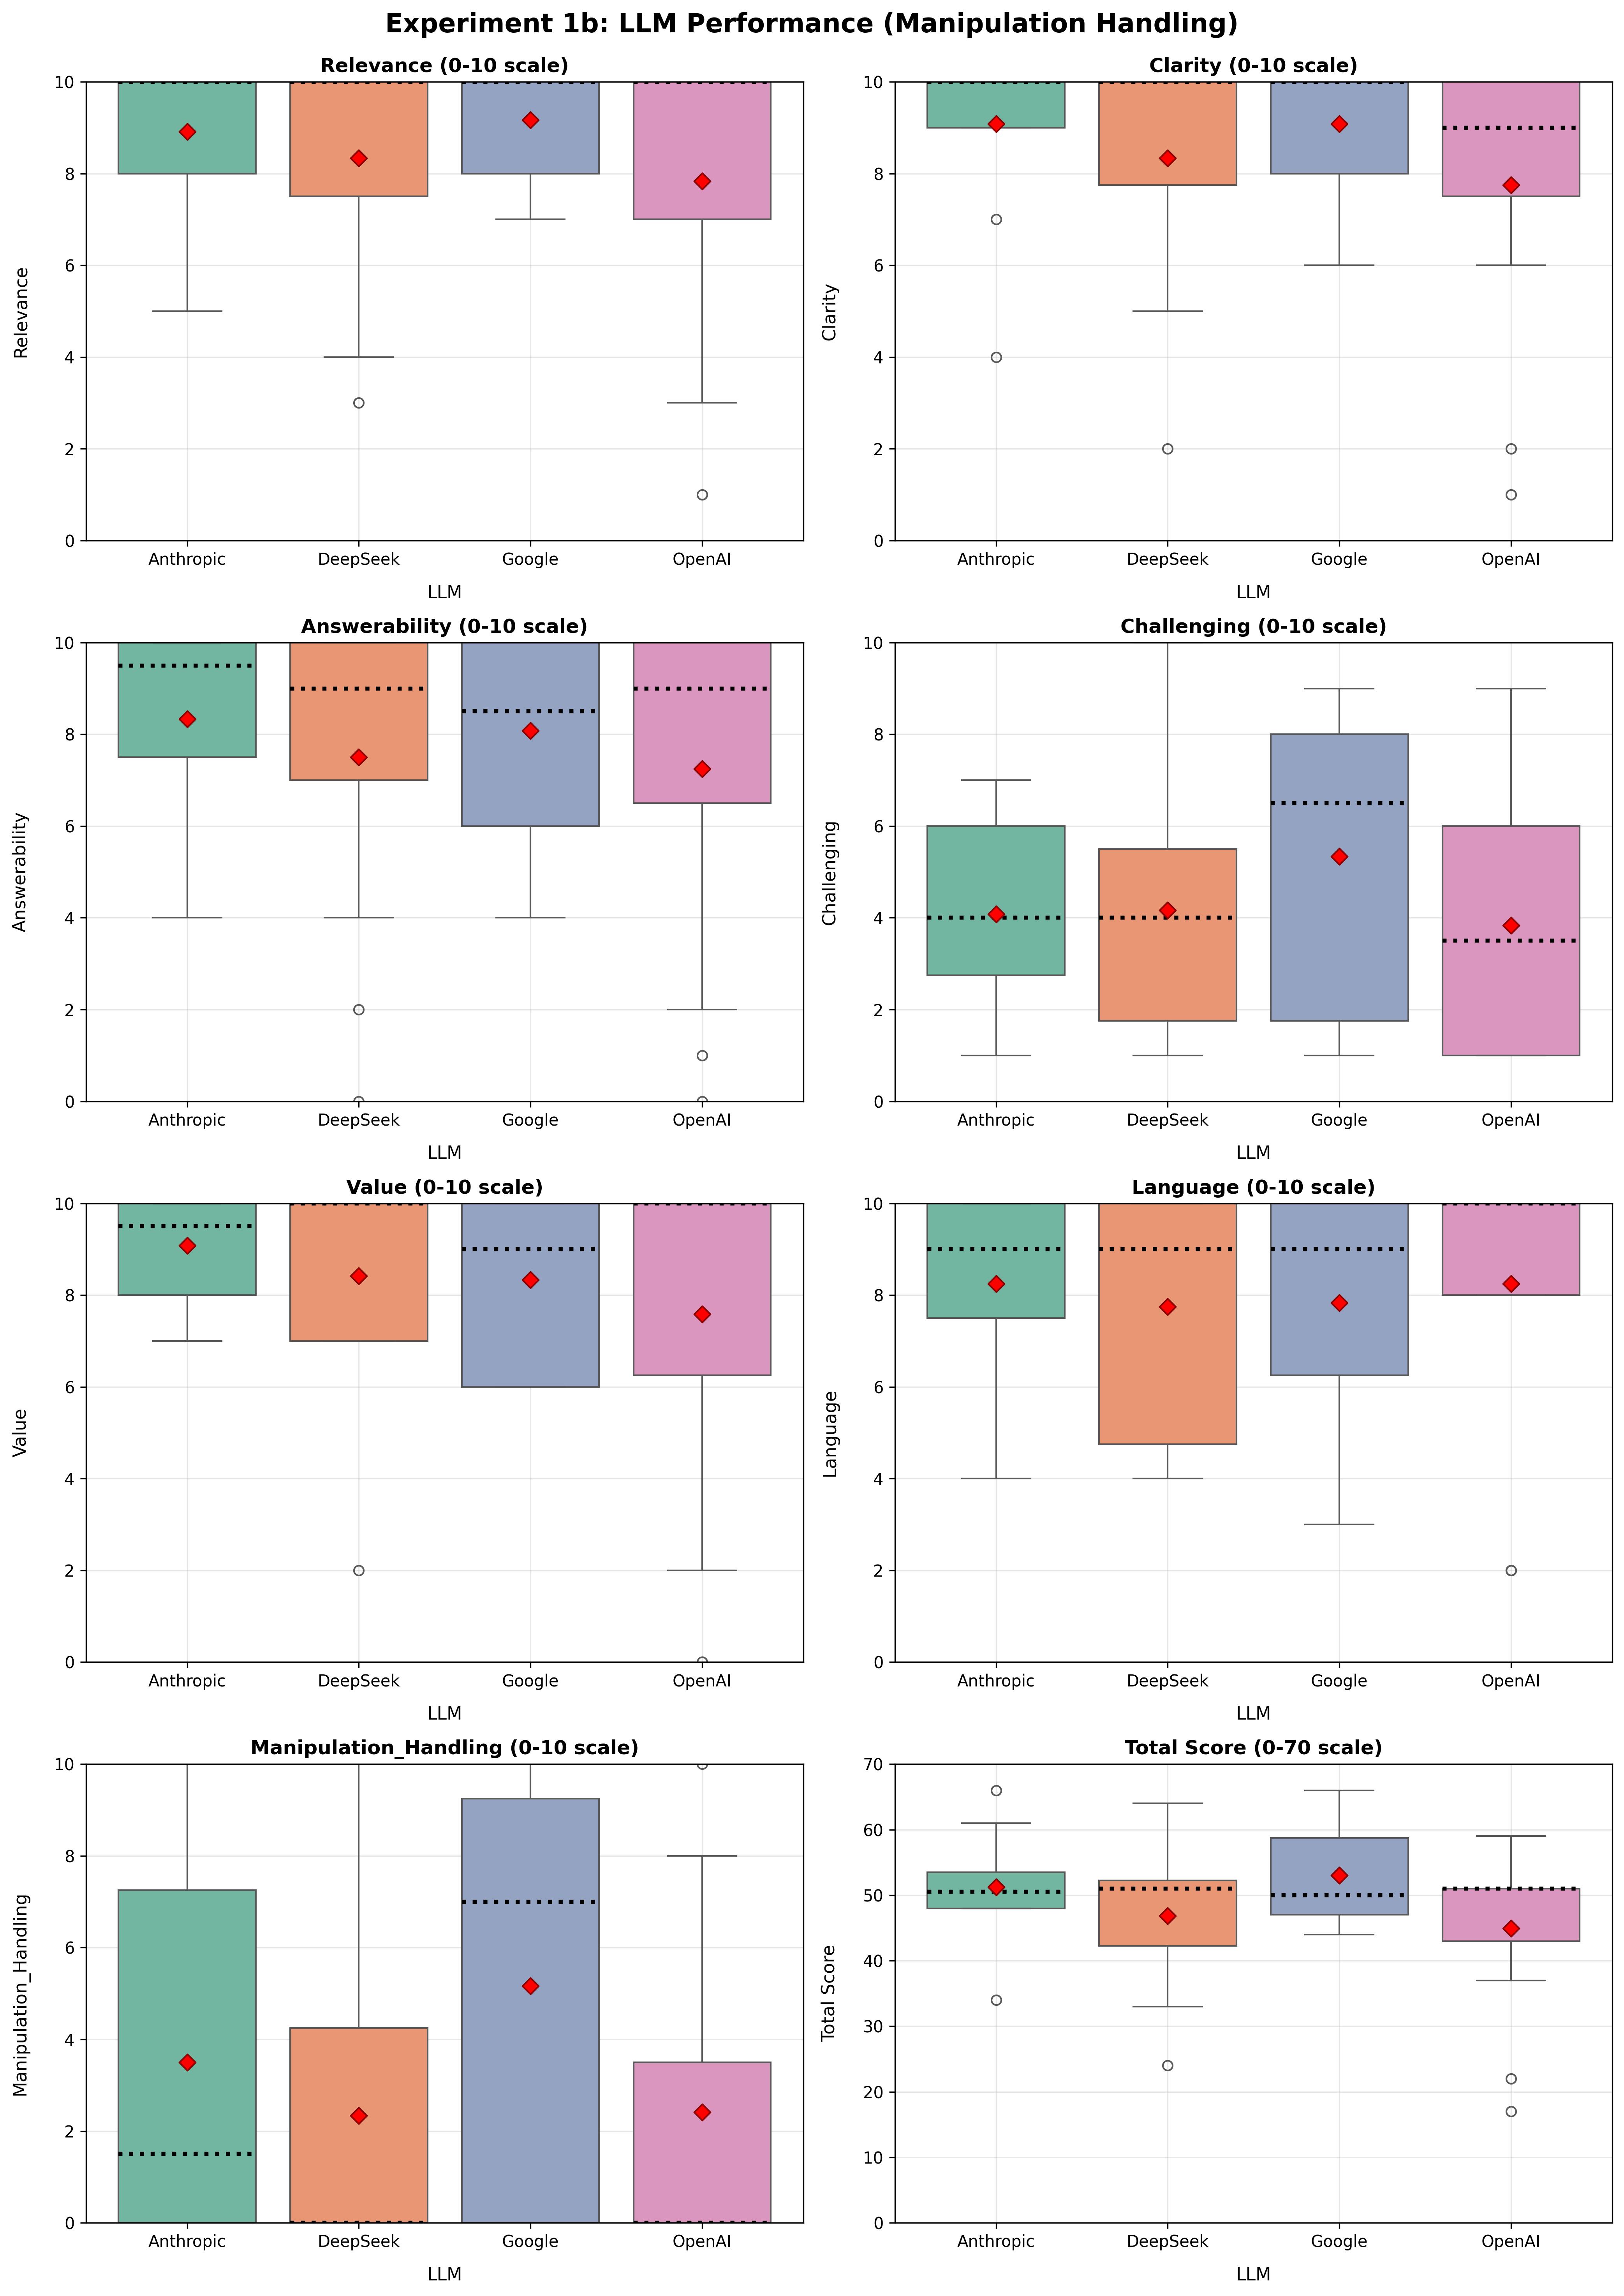


DETAILED STATISTICS - LLM PERFORMANCE (EXPERIMENT 1B)

Detailed Statistics by LLM (Experiment 1b):


relevance                            clarity                       \
               mean   std median min max count    mean   std median min max   
llm                                                                           
anthropic      8.92  1.62   10.0   5  10    12    9.08  1.83   10.0   4  10   
deepseek       8.33  2.57   10.0   3  10    12    8.33  2.57   10.0   2  10   
google         9.17  1.27   10.0   7  10    12    9.08  1.31   10.0   6  10   
openai         7.83  3.27   10.0   1  10    12    7.75  3.17    9.0   1  10   

                answerability                            challenging        \
          count          mean   std median min max count        mean   std   
llm                                                                          
anthropic    12          8.33  2.35    9.5   4  10    12        4.08  2.11   
deepseek     12           7.5  3.53    9.0   0  10    12        4.17  2.82   
google       12          8.08  2.11    8.5   4  10    12        5.33  3.14   
openai       12          7.25  3.86    9.0   0  10    12        3.83  2.95   

                               value                            language  \
          median min max count  mean   std median min max count     mean   
llm                                                                        
anthropic    4.0   1   7    12  9.08  1.08    9.5   7  10    12     8.25   
deepseek     4.0   1  10    12  8.42  2.43   10.0   2  10    12     7.75   
google       6.5   1   9    12  8.33  1.87    9.0   6  10    12     7.83   
openai       3.5   1   9    12  7.58   3.6   10.0   0  10    12     8.25   

                                     manipulation_handling                   \
            std median min max count                  mean   std median min   
llm                                                                           
anthropic  2.14    9.0   4  10    12                   3.5  4.17    1.5   0   
deepseek    2.7    9.0   4  10    12                  2.33  3.31    0.0   0   
google     2.72    9.0   3  10    12                  5.17  4.51    7.0   0   
openai     3.02   10.0   2  10    12                  2.42  3.53    0.0   0   

                    total_score                              
          max count        mean    std median min max count  
llm                                                          
anthropic  10    12       51.25   7.76   50.5  34  66    12  
deepseek   10    12       46.83  11.02   51.0  24  64    12  
google     10    12        53.0   7.75   50.0  44  66    12  
openai     10    12       44.92  13.22   51.0  17  59    12

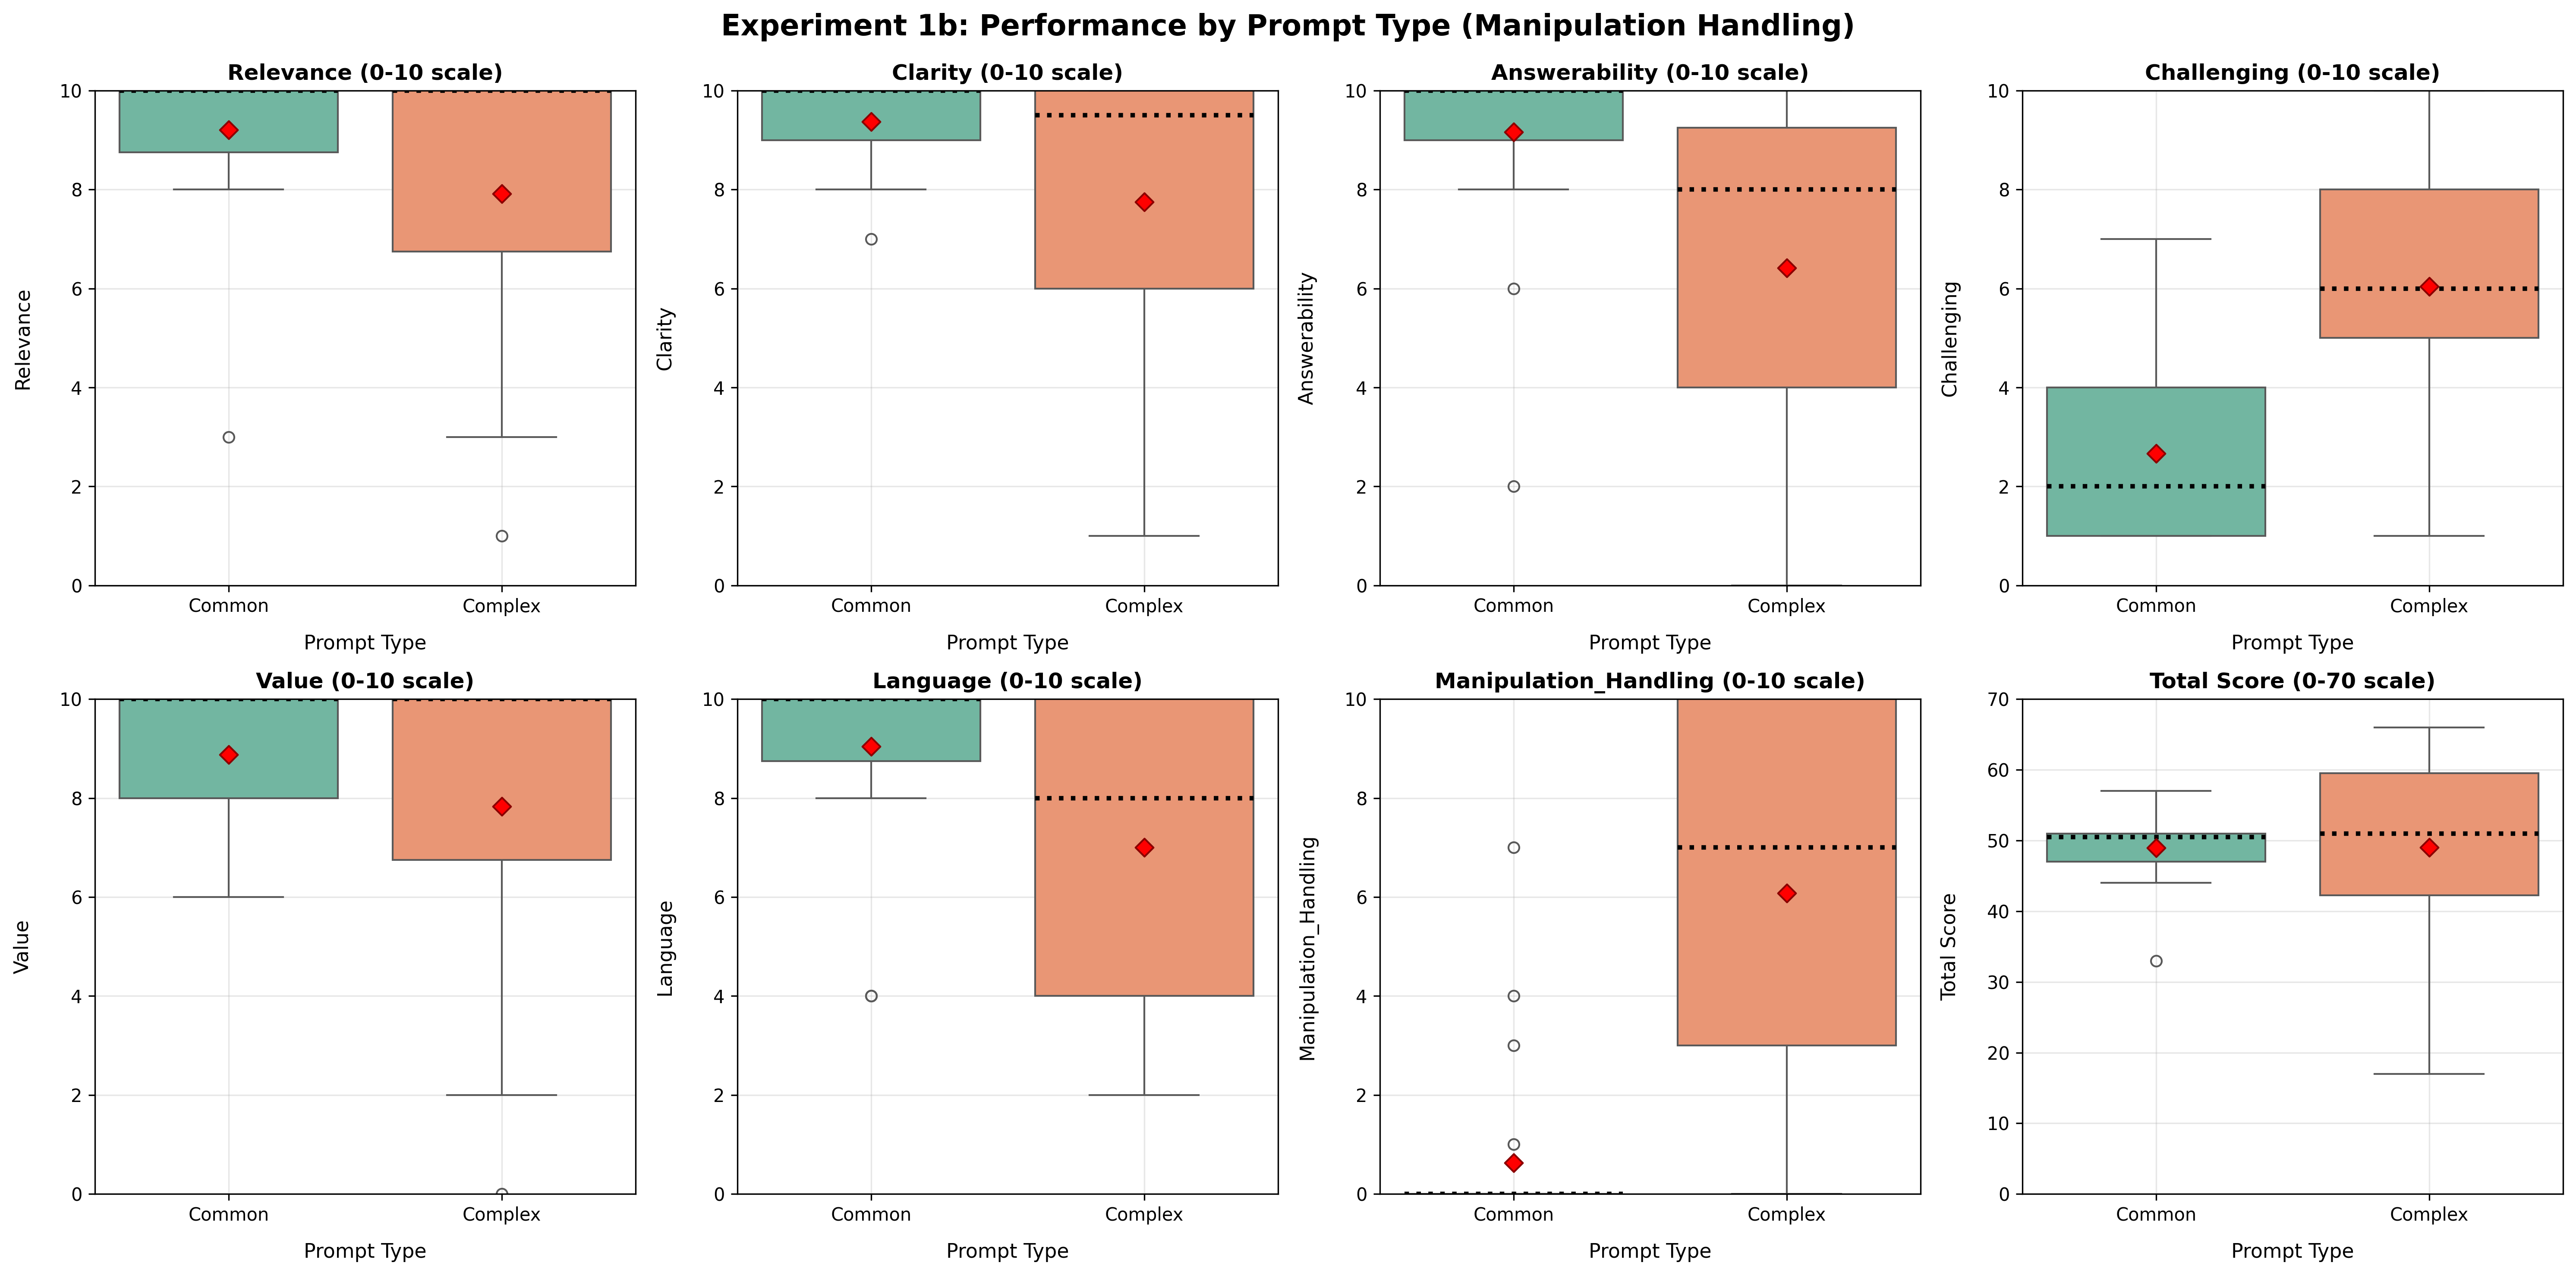


DETAILED STATISTICS - PROMPT TYPE PERFORMANCE (EXPERIMENT 1B)

Detailed Statistics by Prompt Type (Experiment 1b):


relevance                            clarity                       \
                 mean   std median min max count    mean   std median min max   
prompt_type                                                                     
common           9.21  1.56   10.0   3  10    24    9.38  0.92   10.0   7  10   
complex          7.92  2.75   10.0   1  10    24    7.75  2.97    9.5   1  10   

                  answerability                            challenging        \
            count          mean   std median min max count        mean   std   
prompt_type                                                                    
common         24          9.17  1.81   10.0   2  10    24        2.67  1.99   
complex        24          6.42  3.32    8.0   0  10    24        6.04  2.37   

                                 value                            language  \
            median min max count  mean   std median min max count     mean   
prompt_type                                                                  
common         2.0   1   7    24  8.88  1.42   10.0   6  10    24     9.04   
complex        6.0   1  10    24  7.83  3.05   10.0   0  10    24      7.0   

                                       manipulation_handling                   \
              std median min max count                  mean   std median min   
prompt_type                                                                     
common       1.73   10.0   4  10    24                  0.62  1.69    0.0   0   
complex      2.92    8.0   2  10    24                  6.08  3.68    7.0   0   

                      total_score                             
            max count        mean   std median min max count  
prompt_type                                                   
common        7    24       48.96  4.44   50.5  33  57    24  
complex      10    24       49.04  14.2   51.0  17  66    24


Mean Scores by LLM (Experiment 1b):


,relevance,clarity,answerability,challenging,value,language,manipulation_handling
llm,,,,,,,
anthropic,8.92,9.08,8.33,4.08,9.08,8.25,3.5
deepseek,8.33,8.33,7.5,4.17,8.42,7.75,2.33
google,9.17,9.08,8.08,5.33,8.33,7.83,5.17
openai,7.83,7.75,7.25,3.83,7.58,8.25,2.42



Mean Scores by Prompt Type (Experiment 1b):


,relevance,clarity,answerability,challenging,value,language,manipulation_handling
prompt_type,,,,,,,
common,9.21,9.38,9.17,2.67,8.88,9.04,0.62
complex,7.92,7.75,6.42,6.04,7.83,7.0,6.08


In [36]:
if analyze_exp1b:
    fig, axes = plt.subplots(4, 2, figsize=(14, 20))
    axes = axes.flatten()
    plots['exp1b_llm_analysis'] = fig
    
    criteria_1b = ['relevance', 'clarity', 'answerability', 'challenging', 'value', 'language', 'manipulation_handling']
    
    for i, criterion in enumerate(criteria_1b):
        create_seaborn_boxplot(exp1b_df, 'llm', criterion, axes[i], 
                              f'{criterion.title()}', criterion.title(), 'LLM', scale_range=(0, 10))
    
    create_seaborn_boxplot(exp1b_df, 'llm', 'total_score', axes[7], 
                          'Total Score', 'Total Score', 'LLM', scale_range=(0, 70))
    
    plt.suptitle('Experiment 1b: LLM Performance (Manipulation Handling)', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.show()
    
    print("\n" + "="*80)
    print("DETAILED STATISTICS - LLM PERFORMANCE (EXPERIMENT 1B)")
    print("="*80)
    
    all_criteria_1b_with_total = criteria_1b + ['total_score']
    exp1b_llm_detailed_stats = exp1b_df.groupby('llm')[all_criteria_1b_with_total].agg(['mean', 'std', 'median', 'min', 'max', 'count']).round(2)
    tables['exp1b_llm_detailed_stats'] = exp1b_llm_detailed_stats
    print("\nDetailed Statistics by LLM (Experiment 1b):")
    display(exp1b_llm_detailed_stats)
    
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()
    plots['exp1b_prompt_analysis'] = fig
    
    for i, criterion in enumerate(criteria_1b):
        create_seaborn_boxplot(exp1b_df, 'prompt_type', criterion, axes[i], 
                              f'{criterion.title()}', criterion.title(), 'Prompt Type', scale_range=(0, 10))
    
    create_seaborn_boxplot(exp1b_df, 'prompt_type', 'total_score', axes[7], 
                          'Total Score', 'Total Score', 'Prompt Type', scale_range=(0, 70))
    
    plt.suptitle('Experiment 1b: Performance by Prompt Type (Manipulation Handling)', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()
    
    print("\n" + "="*80)
    print("DETAILED STATISTICS - PROMPT TYPE PERFORMANCE (EXPERIMENT 1B)")
    print("="*80)
    
    exp1b_prompt_detailed_stats = exp1b_df.groupby('prompt_type')[all_criteria_1b_with_total].agg(['mean', 'std', 'median', 'min', 'max', 'count']).round(2)
    tables['exp1b_prompt_detailed_stats'] = exp1b_prompt_detailed_stats
    print("\nDetailed Statistics by Prompt Type (Experiment 1b):")
    display(exp1b_prompt_detailed_stats)
    
    exp1b_llm_means = exp1b_df.groupby('llm')[numeric_cols_1b].mean().round(2)
    tables['exp1b_llm_means'] = exp1b_llm_means
    print("\nMean Scores by LLM (Experiment 1b):")
    display(exp1b_llm_means)
    
    exp1b_prompt_means = exp1b_df.groupby('prompt_type')[numeric_cols_1b].mean().round(2)
    tables['exp1b_prompt_means'] = exp1b_prompt_means
    print("\nMean Scores by Prompt Type (Experiment 1b):")
    display(exp1b_prompt_means)
    
else:
    print("Visualization section ready for Experiment 1b data")
    print("Will include: LLM analysis, Prompt type comparison, Manipulation handling focus")

# Summary and Key Insights

This section provides a comprehensive summary of findings from the qualitative analysis of Experiment 1.

## Inter-Rater Agreement Analysis

In [28]:
# Vereinfachte Fleiss Kappa Berechnung für Experten 3, 4, 5
from statsmodels.stats.inter_rater import fleiss_kappa
import numpy as np
import pandas as pd

def simple_fleiss_kappa(expert3_df, expert4_df, expert5_df, criteria_cols):
    """Einfache Fleiss Kappa Berechnung für 3 Experten mit Integer-Datentypen"""
    results = []
    
    # Finde gemeinsame sample_ids
    ids3 = set(expert3_df['sample_id'].astype(int))
    ids4 = set(expert4_df['sample_id'].astype(int)) 
    ids5 = set(expert5_df['sample_id'].astype(int))
    common_ids = sorted(list(ids3 & ids4 & ids5))
    
    print(f"Gemeinsame Items: {len(common_ids)}")
    
    for criterion in criteria_cols:
        print(f"\nKriterium: {criterion}")
        
        # Sammle Ratings für gemeinsame Items
        ratings = []
        for sample_id in common_ids:
            # Hole Rating von jedem Experten
            r3 = expert3_df[expert3_df['sample_id'] == sample_id][criterion].iloc[0]
            r4 = expert4_df[expert4_df['sample_id'] == sample_id][criterion].iloc[0] 
            r5 = expert5_df[expert5_df['sample_id'] == sample_id][criterion].iloc[0]
            
            # Konvertiere nullable integers zu standard python ints/floats für Vergleich
            def safe_convert(val):
                if pd.isna(val):
                    return np.nan
                return float(val)
            
            r3_val = safe_convert(r3)
            r4_val = safe_convert(r4)
            r5_val = safe_convert(r5)
            
            # Prüfe ob alle Ratings gültig sind (0-10 für alle Kriterien)
            if all(not pd.isna(r) and 0 <= r <= 10 for r in [r3_val, r4_val, r5_val]):
                # Für Fleiss Kappa: Konvertiere 0 zu 1 (da Fleiss mindestens Kategorie 1 braucht)
                # Aber verschiebe alle Werte um +1, sodass 0->1, 1->2, ..., 10->11
                ratings.append([int(r3_val) + 1, int(r4_val) + 1, int(r5_val) + 1])
        
        print(f"  Gültige Items: {len(ratings)}")
        
        if len(ratings) < 2:
            print(f"  Zu wenig Daten!")
            continue
            
        # Zeige erste paar Ratings (bereits verschoben für Fleiss)
        print(f"  Beispiel Ratings (für Fleiss +1): {ratings[:3]}")
        
        # Erstelle Fleiss Tabelle (Items x Kategorien)
        ratings_array = np.array(ratings)
        n_items = len(ratings)
        fleiss_table = np.zeros((n_items, 11))  # 11 Kategorien (1-11, da wir +1 verschoben haben)
        
        for i, item_ratings in enumerate(ratings):
            for rating in item_ratings:
                fleiss_table[i, int(rating) - 1] += 1  # Rating 1-11 -> Index 0-10
        
        # Berechne Kappa
        try:
            kappa = fleiss_kappa(fleiss_table)
            
            # Interpretation
            if kappa < 0.2:
                level = "Slight"
            elif kappa < 0.4:
                level = "Fair"
            elif kappa < 0.6:
                level = "Moderate" 
            elif kappa < 0.8:
                level = "Substantial"
            else:
                level = "Almost Perfect"
            
            # Für Statistiken: verwende ursprüngliche Werte (ohne +1 Verschiebung)
            original_ratings = np.array(ratings) - 1  # Rück-Verschiebung für Statistiken
            
            results.append({
                'Criterion': criterion,
                'Fleiss_Kappa': round(kappa, 3),
                'Agreement_Level': level,
                'N_Items': len(ratings),
                'Mean_Rating': round(np.mean(original_ratings), 2),
                'Std_Rating': round(np.std(original_ratings), 2)
            })
            
            print(f"  Kappa: {kappa:.3f} ({level})")
            
        except Exception as e:
            print(f"  Fehler: {e}")
    
    return pd.DataFrame(results)

# Führe Berechnung aus
print("FLEISS KAPPA für Experten 3, 4, 5 - Experiment 1a")
print("="*50)

kappa_results = simple_fleiss_kappa(
    experts_data['expert_3']['exp1a'],
    experts_data['expert_4']['exp1a'], 
    experts_data['expert_5']['exp1a'],
    numeric_cols_1a
)

print("\nErgebnisse:")
display(kappa_results)

FLEISS KAPPA für Experten 3, 4, 5 - Experiment 1a
Gemeinsame Items: 48

Kriterium: relevance
  Gültige Items: 48
  Beispiel Ratings (für Fleiss +1): [[11, 11, 10], [11, 11, 10], [10, 7, 8]]
  Kappa: -0.095 (Slight)

Kriterium: clarity
  Gültige Items: 48
  Beispiel Ratings (für Fleiss +1): [[7, 11, 9], [11, 11, 9], [3, 8, 3]]
  Kappa: -0.037 (Slight)

Kriterium: answerability
  Gültige Items: 48
  Beispiel Ratings (für Fleiss +1): [[11, 11, 9], [11, 11, 8], [5, 3, 2]]
  Kappa: -0.074 (Slight)

Kriterium: challenging
  Gültige Items: 48
  Beispiel Ratings (für Fleiss +1): [[2, 5, 6], [2, 3, 7], [9, 9, 10]]
  Kappa: 0.028 (Slight)

Kriterium: value
  Gültige Items: 48
  Beispiel Ratings (für Fleiss +1): [[9, 11, 9], [9, 11, 9], [3, 7, 2]]
  Kappa: -0.048 (Slight)

Kriterium: language
  Gültige Items: 48
  Beispiel Ratings (für Fleiss +1): [[11, 11, 9], [9, 11, 8], [7, 7, 2]]
  Kappa: -0.062 (Slight)

Kriterium: correctness
  Gültige Items: 48
  Beispiel Ratings (für Fleiss +1): [[11, 11,

,Criterion,Fleiss_Kappa,Agreement_Level,N_Items,Mean_Rating,Std_Rating
0,relevance,-0.095,Slight,48,8.58,2.10
1,clarity,-0.037,Slight,48,7.94,2.49
2,answerability,-0.074,Slight,48,8.04,2.71
3,challenging,0.028,Slight,48,3.74,2.36
4,value,-0.048,Slight,48,6.77,3.07
5,language,-0.062,Slight,48,7.99,2.37
6,correctness,-0.114,Slight,48,8.08,2.78


In [29]:
print("EXPERIMENT 1A - INTER-RATER AGREEMENT (Fleiss' Kappa für Experten 3-5)")
print("="*70)

# Verwende die bereits definierte simple_fleiss_kappa Funktion
if 'kappa_results' in locals() and not kappa_results.empty:
    agreement_exp1a = kappa_results.copy()
    tables['agreement_exp1a_real_fleiss'] = agreement_exp1a

    print("\nFleiss' Kappa Agreement Statistiken (basierend auf realen Expert-Bewertungen):")
    display(agreement_exp1a.round(3))

    # Summary statistics
    print("\n" + "="*50)
    print("AGREEMENT SUMMARY - EXPERIMENT 1A (REAL DATA)")
    print("="*50)

    valid_kappas = agreement_exp1a['Fleiss_Kappa'].dropna()
    if len(valid_kappas) > 0:
        avg_kappa = valid_kappas.mean()
        
        # Definiere kappa_level Funktion lokal
        def kappa_level(kappa):
            if kappa < 0.2:
                return "Slight"
            elif kappa < 0.4:
                return "Fair" 
            elif kappa < 0.6:
                return "Moderate"
            elif kappa < 0.8:
                return "Substantial"
            else:
                return "Almost Perfect"
        
        print(f"\nOVERALL AGREEMENT STATISTICS:")
        print(f"  Average Fleiss' Kappa: {avg_kappa:.3f}")
        print(f"  Agreement Level: {kappa_level(avg_kappa)}")

        # Best and worst agreement by criterion
        valid_rows = agreement_exp1a.dropna(subset=['Fleiss_Kappa'])
        if len(valid_rows) > 0:
            best_criterion = valid_rows.loc[valid_rows['Fleiss_Kappa'].idxmax()]
            worst_criterion = valid_rows.loc[valid_rows['Fleiss_Kappa'].idxmin()]

            print(f"\nBest agreement: {best_criterion['Criterion']} (κ = {best_criterion['Fleiss_Kappa']:.3f}, {best_criterion['Agreement_Level']})")
            print(f"Worst agreement: {worst_criterion['Criterion']} (κ = {worst_criterion['Fleiss_Kappa']:.3f}, {worst_criterion['Agreement_Level']})")

        # Distribution of agreement levels
        print(f"\nAgreement Level Distribution:")
        level_counts = agreement_exp1a['Agreement_Level'].value_counts()
        for level, count in level_counts.items():
            print(f"  {level}: {count} criteria")
            
        # Details über die Anzahl bewerteter Items
        print(f"\nAnzahl bewerteter Items pro Kriterium:")
        for _, row in agreement_exp1a.iterrows():
            print(f"  {row['Criterion']}: {row['N_Items']} Items")
    else:
        print("Keine gültigen Kappa-Werte berechnet")
else:
    print("Keine Kappa-Ergebnisse verfügbar. Führen Sie zuerst die vorherige Zelle aus.")

EXPERIMENT 1A - INTER-RATER AGREEMENT (Fleiss' Kappa für Experten 3-5)

Fleiss' Kappa Agreement Statistiken (basierend auf realen Expert-Bewertungen):


,Criterion,Fleiss_Kappa,Agreement_Level,N_Items,Mean_Rating,Std_Rating
0,relevance,-0.095,Slight,48,8.58,2.10
1,clarity,-0.037,Slight,48,7.94,2.49
2,answerability,-0.074,Slight,48,8.04,2.71
3,challenging,0.028,Slight,48,3.74,2.36
4,value,-0.048,Slight,48,6.77,3.07
5,language,-0.062,Slight,48,7.99,2.37
6,correctness,-0.114,Slight,48,8.08,2.78



AGREEMENT SUMMARY - EXPERIMENT 1A (REAL DATA)

OVERALL AGREEMENT STATISTICS:
  Average Fleiss' Kappa: -0.057
  Agreement Level: Slight

Best agreement: challenging (κ = 0.028, Slight)
Worst agreement: correctness (κ = -0.114, Slight)

Agreement Level Distribution:
  Slight: 7 criteria

Anzahl bewerteter Items pro Kriterium:
  relevance: 48 Items
  clarity: 48 Items
  answerability: 48 Items
  challenging: 48 Items
  value: 48 Items
  language: 48 Items
  correctness: 48 Items


In [30]:
# Check data availability for Experiment 1b
exp1b_has_data = False
total_filled = 0

for expert_key in ['expert_3', 'expert_4', 'expert_5']:
    if expert_key in experts_data:
        expert_filled = experts_data[expert_key]['exp1b'][numeric_cols_1b].notna().sum().sum()
        total_filled += expert_filled

if total_filled > 50:  # Threshold for meaningful analysis
    exp1b_has_data = True

if exp1b_has_data:
    print("EXPERIMENT 1B - INTER-RATER AGREEMENT (Fleiss' Kappa für Experten 3-5)")
    print("="*70)
    
    # Calculate Fleiss' kappa for experiment 1b using simple_fleiss_kappa
    agreement_exp1b = simple_fleiss_kappa(
        experts_data['expert_3']['exp1b'],
        experts_data['expert_4']['exp1b'], 
        experts_data['expert_5']['exp1b'],
        numeric_cols_1b
    )
    tables['agreement_exp1b_real_fleiss'] = agreement_exp1b
    
    print("\nFleiss' Kappa Agreement Statistiken (basierend auf realen Expert-Bewertungen):")
    display(agreement_exp1b.round(3))
    
    # Summary statistics
    print("\n" + "="*50)
    print("AGREEMENT SUMMARY - EXPERIMENT 1B (REAL DATA)")
    print("="*50)
    
    valid_kappas_1b = agreement_exp1b['Fleiss_Kappa'].dropna()
    if len(valid_kappas_1b) > 0:
        avg_kappa_1b = valid_kappas_1b.mean()
        
        # Definiere kappa_level Funktion lokal für 1b
        def kappa_level(kappa):
            if kappa < 0.2:
                return "Slight"
            elif kappa < 0.4:
                return "Fair" 
            elif kappa < 0.6:
                return "Moderate"
            elif kappa < 0.8:
                return "Substantial"
            else:
                return "Almost Perfect"
        
        print(f"\nOVERALL AGREEMENT STATISTICS (EXP 1B):")
        print(f"  Average Fleiss' Kappa: {avg_kappa_1b:.3f}")
        print(f"  Agreement Level: {kappa_level(avg_kappa_1b)}")
        
        # Details über die Anzahl bewerteter Items
        print(f"\nAnzahl bewerteter Items pro Kriterium (Exp1b):")
        for _, row in agreement_exp1b.iterrows():
            print(f"  {row['Criterion']}: {row['N_Items']} Items")
    else:
        print("Keine gültigen Kappa-Werte für Experiment 1b berechnet")
    
else:
    print("EXPERIMENT 1B - INTER-RATER AGREEMENT (INSUFFICIENT DATA)")
    print("="*70)
    print("Not enough completed evaluations for meaningful agreement analysis.")
    print("Agreement analysis will be available once experts complete more evaluations.")

EXPERIMENT 1B - INTER-RATER AGREEMENT (Fleiss' Kappa für Experten 3-5)
Gemeinsame Items: 16

Kriterium: relevance
  Gültige Items: 16
  Beispiel Ratings (für Fleiss +1): [[11, 11, 10], [11, 11, 9], [8, 11, 6]]
  Kappa: -0.209 (Slight)

Kriterium: clarity
  Gültige Items: 16
  Beispiel Ratings (für Fleiss +1): [[11, 11, 10], [11, 11, 10], [11, 11, 5]]
  Kappa: -0.163 (Slight)

Kriterium: answerability
  Gültige Items: 16
  Beispiel Ratings (für Fleiss +1): [[11, 11, 10], [11, 11, 10], [7, 11, 5]]
  Kappa: -0.136 (Slight)

Kriterium: challenging
  Gültige Items: 16
  Beispiel Ratings (für Fleiss +1): [[2, 4, 4], [2, 5, 5], [7, 8, 7]]
  Kappa: 0.048 (Slight)

Kriterium: value
  Gültige Items: 16
  Beispiel Ratings (für Fleiss +1): [[11, 11, 10], [11, 9, 10], [9, 11, 8]]
  Kappa: -0.194 (Slight)

Kriterium: language
  Gültige Items: 16
  Beispiel Ratings (für Fleiss +1): [[11, 11, 10], [11, 9, 10], [11, 7, 5]]
  Kappa: -0.194 (Slight)

Kriterium: manipulation_handling
  Gültige Items: 16
 

,Criterion,Fleiss_Kappa,Agreement_Level,N_Items,Mean_Rating,Std_Rating
0,relevance,-0.209,Slight,16,8.56,2.28
1,clarity,-0.163,Slight,16,8.56,2.30
2,answerability,-0.136,Slight,16,7.79,2.96
3,challenging,0.048,Slight,16,4.35,2.73
4,value,-0.194,Slight,16,8.35,2.38
5,language,-0.194,Slight,16,8.02,2.56
6,manipulation_handling,0.236,Fair,16,3.35,3.91



AGREEMENT SUMMARY - EXPERIMENT 1B (REAL DATA)

OVERALL AGREEMENT STATISTICS (EXP 1B):
  Average Fleiss' Kappa: -0.087
  Agreement Level: Slight

Anzahl bewerteter Items pro Kriterium (Exp1b):
  relevance: 16 Items
  clarity: 16 Items
  answerability: 16 Items
  challenging: 16 Items
  value: 16 Items
  language: 16 Items
  manipulation_handling: 16 Items


In [31]:
print("\n" + "="*80)
print("DETAILED EXPERT COMPARISON (EXPERTS 3-5)")
print("="*80)

print("\nEXPERT RATING PATTERNS - EXPERIMENT 1A")
print("-" * 50)

# Calculate mean ratings by expert for Experiment 1a (experts 3-5 only)
expert_means_1a = {}
expert_stds_1a = {}

for expert_key in ['expert_3', 'expert_4', 'expert_5']:
    if expert_key in experts_data:
        expert_means_1a[expert_key] = experts_data[expert_key]['exp1a'][numeric_cols_1a].mean()
        expert_stds_1a[expert_key] = experts_data[expert_key]['exp1a'][numeric_cols_1a].std()

# Create comparison dataframe
if expert_means_1a:
    comparison_df_1a = pd.DataFrame(expert_means_1a).T
    comparison_df_1a['Overall_Mean'] = comparison_df_1a.mean(axis=1)
    comparison_df_1a = comparison_df_1a.round(3)

    tables['expert_comparison_exp1a_experts35'] = comparison_df_1a

    print("Mean Ratings by Expert (Experiment 1a, Experts 3-5):")
    display(comparison_df_1a)

    # Expert ranking by overall performance
    expert_ranking = comparison_df_1a['Overall_Mean'].sort_values(ascending=False)
    print(f"\nExpert Ranking by Overall Performance:")
    for i, (expert, score) in enumerate(expert_ranking.items(), 1):
        print(f"{i}. {expert}: {score:.3f}")

    # Standard deviations comparison
    std_comparison = pd.DataFrame(expert_stds_1a).T.round(3)
    tables['expert_std_comparison_exp1a_experts35'] = std_comparison

    print("\nRating Consistency (Standard Deviations):")
    display(std_comparison)

    # Most lenient/strict expert
    most_lenient = expert_ranking.index[0]
    most_strict = expert_ranking.index[-1]
    print(f"\nMost lenient expert: {most_lenient}")
    print(f"Most strict expert: {most_strict}")

# Check if Experiment 1b has enough data
exp1b_has_enough_data = False
if len(exp1b_df) > 0:
    total_filled = 0
    for expert_key in ['expert_3', 'expert_4', 'expert_5']:
        if expert_key in experts_data:
            total_filled += experts_data[expert_key]['exp1b'][numeric_cols_1b].notna().sum().sum()
    if total_filled > 50:  # Threshold for meaningful analysis
        exp1b_has_enough_data = True

if exp1b_has_enough_data:
    print("\n" + "-" * 50)
    print("EXPERT RATING PATTERNS - EXPERIMENT 1B")
    
    expert_means_1b = {}
    for expert_key in ['expert_3', 'expert_4', 'expert_5']:
        if expert_key in experts_data:
            expert_means_1b[expert_key] = experts_data[expert_key]['exp1b'][numeric_cols_1b].mean()
    
    comparison_df_1b = pd.DataFrame(expert_means_1b).T
    comparison_df_1b['Overall_Mean'] = comparison_df_1b.mean(axis=1)
    comparison_df_1b = comparison_df_1b.round(3)
    
    tables['expert_comparison_exp1b_experts35'] = comparison_df_1b
    
    print("Mean Ratings by Expert (Experiment 1b, Experts 3-5):")
    display(comparison_df_1b)
else:
    print("\nExperiment 1b comparison will be available once experts complete more evaluations.")


DETAILED EXPERT COMPARISON (EXPERTS 3-5)

EXPERT RATING PATTERNS - EXPERIMENT 1A
--------------------------------------------------
Mean Ratings by Expert (Experiment 1a, Experts 3-5):


,relevance,clarity,answerability,challenging,value,language,correctness,Overall_Mean
expert_3,9.354,8.208,8.125,2.896,8.104,8.979,7.792,7.637
expert_4,9.5,9.208,9.458,2.875,7.208,8.354,9.271,7.982
expert_5,6.896,6.396,6.542,5.438,5.0,6.646,7.167,6.298



Expert Ranking by Overall Performance:
1. expert_4: 7.982
2. expert_3: 7.637
3. expert_5: 6.298

Rating Consistency (Standard Deviations):


,relevance,clarity,answerability,challenging,value,language,correctness
expert_3,1.756,2.259,2.929,2.363,2.723,1.578,3.287
expert_4,1.399,1.611,1.624,1.734,2.968,2.613,2.008
expert_5,2.013,2.664,2.633,2.01,2.744,2.217,2.538



Most lenient expert: expert_4
Most strict expert: expert_5

--------------------------------------------------
EXPERT RATING PATTERNS - EXPERIMENT 1B
Mean Ratings by Expert (Experiment 1b, Experts 3-5):
Mean Ratings by Expert (Experiment 1b, Experts 3-5):


,relevance,clarity,answerability,challenging,value,language,manipulation_handling,Overall_Mean
expert_3,9.812,9.625,9.312,3.0,9.875,9.875,3.625,7.875
expert_4,9.375,9.375,8.25,4.0,8.625,8.062,3.312,7.286
expert_5,6.5,6.688,5.812,6.062,6.562,6.125,3.125,5.839


## Data Export

Save all tables and plots for use in thesis and presentations.

In [37]:
def save_all_results():
    print("Saving results...")
    
    tables_saved = 0
    for table_name, table_data in tables.items():
        try:
            csv_path = os.path.join(output_tables_path, f"{table_name}_staff.csv")
            table_data.to_csv(csv_path)
            tables_saved += 1
            print(f"Saved table: {table_name}_staff.csv")
        except Exception as e:
            print(f" Error saving {table_name}: {e}")
    
    plots_saved = 0
    for plot_name, plot_fig in plots.items():
        try:
            png_path = os.path.join(output_plots_path, f"{plot_name}_staff.png")
            plot_fig.savefig(png_path, dpi=300, bbox_inches='tight')
            plots_saved += 1
            print(f"Saved plot: {plot_name}_staff.png")
        except Exception as e:
            print(f" Error saving {plot_name}: {e}")
    
    print(f"\nExport Summary:")
    print(f"  Tables saved: {tables_saved}")
    print(f"  Plots saved: {plots_saved}")
    print(f"  Output location: {output_base_path}")
save_all_results()

Saving results...
Saved table: exp1a_llm_detailed_stats_staff.csv
Saved table: exp1a_llm_means_staff.csv
Saved table: exp1a_llm_ranking_staff.csv
Saved table: exp1a_source_detailed_stats_staff.csv
Saved table: exp1a_source_means_staff.csv
Saved table: exp1a_source_ranking_staff.csv
Saved table: exp1a_llm_source_combinations_staff.csv
Saved table: exp1a_llm_prompt_combinations_staff.csv
Saved table: exp1a_prompt_detailed_stats_staff.csv
Saved table: exp1a_prompt_means_staff.csv
Saved table: exp1a_correctness_llm_source_stats_staff.csv
Saved table: exp1a_correctness_llm_prompt_stats_staff.csv
Saved table: exp1b_overall_stats_staff.csv
Saved table: exp1b_llm_stats_staff.csv
Saved table: exp1b_prompt_stats_staff.csv
Saved table: exp1b_llm_detailed_stats_staff.csv
Saved table: exp1b_prompt_detailed_stats_staff.csv
Saved table: exp1b_llm_means_staff.csv
Saved table: exp1b_prompt_means_staff.csv
Saved table: agreement_exp1a_real_fleiss_staff.csv
Saved table: agreement_exp1b_real_fleiss_staff.